<h1 style="
    background-color: #191970; 
    color: white; 
    text-align: center; 
    padding: 20px; 
    border-radius: 15px; 
    font-family: 'Arial Black', Gadget, sans-serif;
    box-shadow: 3px 3px 10px rgba(0,0,0,0.2);
">
SMS Spam Classification
</h1>

<h2 style="
    color: #8B4513; 
    text-align: center; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 15px;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.3);
">
PHASE 1: PROJECT SETUP AND ENVIRONMENT CONFIGURATION
</h2>

In [1]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.metrics import ConfusionMatrixDisplay
import joblib
from scipy import sparse
import time
from collections import Counter
from scipy.special import expit

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')
np.random.seed(42)

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

True

<h2 style="
    color: #8B4513; 
    text-align: center; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 15px;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.3);
">
PHASE 2: DATA ACQUISITION AND INITIAL INSPECTION
</h2>

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 1: Load Dataset
</h3>

In [2]:
data_path = "SMSSpamCollection"  # Define path to SMS Spam Collection dataset file

df = pd.read_csv(data_path, sep='\t', header=None, names=['label', 'message'])  # Read dataset file with tab separator and no header

print("Dataset loaded successfully")  # Confirmation message indicating successful dataset loading

print(f"Dataset shape: {df.shape}")  # Print dataset shape (rows, columns)

print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")  # Print detailed row and column count

print("\n" + "="*80)  # Separator line for clarity in output

print("\nFirst 5 rows of the dataset:")  # Header for first 5 rows
print(df.head())  # Display first 5 rows of dataset

Dataset loaded successfully
Dataset shape: (5572, 2)
Number of rows: 5572, Number of columns: 2


First 5 rows of the dataset:
  label  \
0   ham   
1   ham   
2  spam   
3   ham   
4   ham   

                                                                                                                                                       message  
0                                              Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...  
1                                                                                                                                Ok lar... Joking wif u oni...  
2  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's  
3                                                                                                            U dun say so early hor... U c already then say...  
4

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 2: Check Data Quality
</h3>

In [3]:
missing_values = df.isnull().sum()  # Calculate sum of missing values for each column

print("Missing values per column:")  # Header for missing values section
print(missing_values)  # Display missing value counts per column

print("\n" + "="*80)  # Separator line for clarity

duplicate_count = df.duplicated().sum()  # Count number of duplicate rows

print(f"Number of duplicate rows: {duplicate_count}")  # Print duplicate count
print(f"Percentage of duplicates: {(duplicate_count/len(df))*100:.2f}%")  # Print duplicate percentage

df_original = df.copy()  # Backup copy of original dataset

df = df.drop_duplicates().reset_index(drop=True)  # Remove duplicates and reset index

print(f"Dataset shape after removing duplicates: {df.shape}")  # Print updated dataset shape

print("\n" + "="*80)  # Separator line for clarity

Missing values per column:
label      0
message    0
dtype: int64

Number of duplicate rows: 403
Percentage of duplicates: 7.23%
Dataset shape after removing duplicates: (5169, 2)



<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 3: Analyze Class Distribution
</h3>

In [4]:
class_distribution = df['label'].value_counts()  # Count occurrences for each class label
class_percentages = df['label'].value_counts(normalize=True) * 100  # Calculate percentage distribution per class

print("Class distribution analysis:")  # Header for class distribution

print(f"Ham messages: {class_distribution.get('ham', 0)} ({class_percentages.get('ham', 0):.2f}%)")  # Ham count and percentage
print(f"Spam messages: {class_distribution.get('spam', 0)} ({class_percentages.get('spam', 0):.2f}%)")  # Spam count and percentage

print("\n" + "="*90)  # Separator line

print("\nSample messages from each class:")  # Header for sample messages

print("\nHAM message examples:")  # Subheader for ham examples
ham_samples = df[df['label'] == 'ham'].sample(3, random_state=42)  # Sample 3 random ham messages

for idx, row in ham_samples.iterrows():  # Iterate through sampled ham messages
    print(f"- {row['message'][:80]}...")  # Display truncated ham messages

print("\nSPAM message examples:")  # Subheader for spam examples
spam_samples = df[df['label'] == 'spam'].sample(3, random_state=42)  # Sample 3 random spam messages

for idx, row in spam_samples.iterrows():  # Iterate through sampled spam messages
    print(f"- {row['message'][:80]}...")  # Display truncated spam messages

print("\n" + "="*90)  # Separator line

Class distribution analysis:
Ham messages: 4516 (87.37%)
Spam messages: 653 (12.63%)


Sample messages from each class:

HAM message examples:
- Sorry, I can't help you on this....
- How's my loverboy doing ? What does he do that keeps him from coming to his Quee...
- Sitting in mu waiting for everyone to get out of my suite so I can take a shower...

SPAM message examples:
- Romantic Paris. 2 nights, 2 flights from £79 Book now 4 next year. Call 08704439...
- URGENT! Your mobile No *********** WON a £2,000 Bonus Caller Prize on 02/06/03! ...
- Free 1st week entry 2 TEXTPOD 4 a chance 2 win 40GB iPod or £250 cash every wk. ...



<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 4: Visualize Class Distribution
</h3>

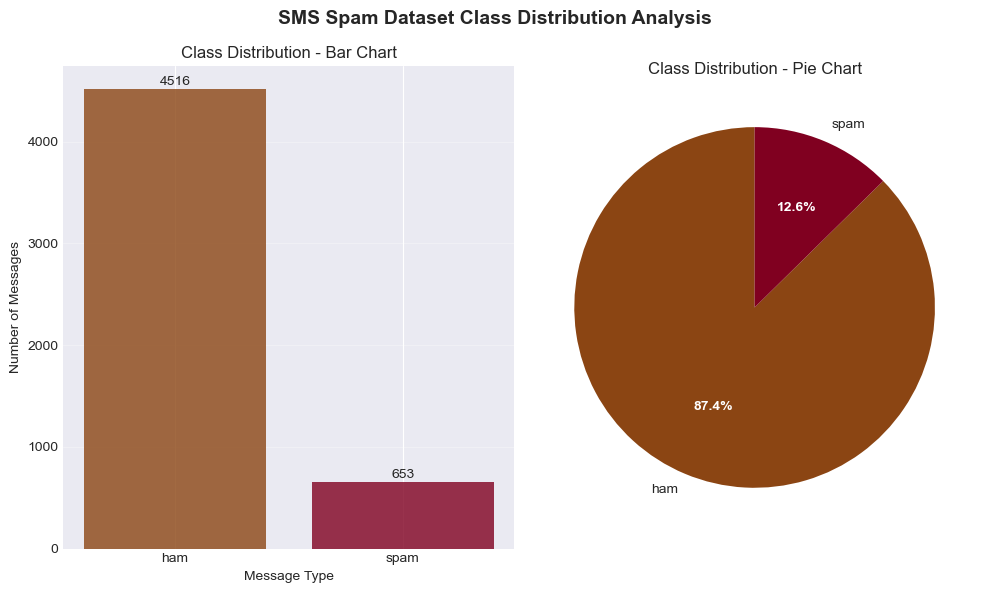

In [5]:
plt.figure(figsize=(10, 6))  # Create figure with specified dimensions

ax1 = plt.subplot(1, 2, 1)  # First subplot for bar chart

colors = ['#8B4513', '#800020'] # Two-piece colors: dark green (ham), dark red (spam)

bars = ax1.bar(class_distribution.index, class_distribution.values, color=colors, alpha=0.8)  # Bar chart with class counts

ax1.set_xlabel('Message Type')  # Set x-axis label
ax1.set_ylabel('Number of Messages')  # Set y-axis label
ax1.set_title('Class Distribution - Bar Chart')  # Set bar chart title
ax1.grid(True, alpha=0.3, axis='y')  # Add grid lines to y-axis

for bar in bars:  # Add value labels on top of each bar
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{int(height)}', ha='center', va='bottom')

ax2 = plt.subplot(1, 2, 2)  # Second subplot for pie chart

wedges, texts, autotexts = ax2.pie(class_percentages.values, labels=class_percentages.index,  # Pie chart with percentages
                                   autopct='%1.1f%%', colors=colors, startangle=90)

ax2.set_title('Class Distribution - Pie Chart')  # Set pie chart title

for autotext in autotexts:  # Customize pie chart text appearance
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.suptitle('SMS Spam Dataset Class Distribution Analysis', fontsize=14, fontweight='bold')  # Main title
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()  # Display visualization

<h2 style="
    color: #8B4513; 
    text-align: center; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 15px;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.3);
">
PHASE 3: TEXT PREPROCESSING
</h2>

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 5: Define POS Tag Conversion Function
</h3>

In [6]:
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):  # Adjective
        return wordnet.ADJ  # Return WordNet adjective tag
    elif treebank_tag.startswith('V'):  # Verb
        return wordnet.VERB  # Return WordNet verb tag
    elif treebank_tag.startswith('N'):  # Noun
        return wordnet.NOUN  # Return WordNet noun tag
    elif treebank_tag.startswith('R'):  # Adverb
        return wordnet.ADV  # Return WordNet adverb tag
    else:  # Default for other tags
        return wordnet.NOUN  # Return WordNet noun tag as default

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 6: Define Text Preprocessing Function
</h3>

In [7]:
def preprocess_text(text, lemmatize=True, remove_stopwords=True):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r'\S*@\S*\s?', '', text)  # Remove emails
    text = re.sub(r'[^a-zA-Z\s\.\?!,]', ' ', text)  # Remove special chars/numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace
    
    tokens = word_tokenize(text)  # Tokenize text
    pos_tags = pos_tag(tokens)  # POS tagging
    
    lemmatizer = WordNetLemmatizer()  # Initialize lemmatizer
    stop_words = set(stopwords.words('english'))  # Load stopwords
    
    processed_tokens = []  # List to store processed tokens
    
    for token, tag in pos_tags:  # Iterate through tokens and tags
        if remove_stopwords and token in stop_words:  # Skip stopwords
            continue
        if lemmatize:  # Apply lemmatization if enabled
            wordnet_pos = get_wordnet_pos(tag)  # Convert POS tag
            token = lemmatizer.lemmatize(token, wordnet_pos)  # Lemmatize token
        if len(token) > 1:  # Keep tokens longer than 1 character
            processed_tokens.append(token)  # Add to processed list
    
    return ' '.join(processed_tokens)  # Join tokens back to string

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 7: Test Preprocessing Function
</h3>

In [8]:
print("Testing text preprocessing function...")  # Header for preprocessing test

test_samples = df.sample(3, random_state=42)  # Select 3 random samples for testing

for idx, row in test_samples.iterrows():  # Iterate through test samples
    original_text = row['message']  # Extract original text
    processed_text = preprocess_text(original_text)  # Apply preprocessing function
    print(f"\nOriginal ({row['label']}): {original_text[:80]}...")  # Display truncated original
    print(f"Processed: {processed_text[:80]}...")  # Display truncated processed text

print("\n" + "="*80)  # Separator line

Testing text preprocessing function...

Original (ham): K, makes sense, btw carlos is being difficult so you guys are gonna smoke while ...
Processed: make sense btw carlos difficult guy gon na smoke go pick second batch get gas...

Original (spam): URGENT! Your mobile No *********** WON a £2,000 Bonus Caller Prize on 02/06/03! ...
Processed: urgent mobile bonus caller prize nd attempt reach call asap box qp ppm...

Original (ham): If you still havent collected the dough pls let me know so i can go to the place...
Processed: still havent collect dough pls let know go place send get control number...



<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 8: Apply Preprocessing to Entire Dataset
</h3>

In [9]:
print("Applying text preprocessing to entire dataset...")  # Status message

start_time = time.time()  # Record start time

df['clean_text'] = df['message'].apply(lambda x: preprocess_text(x))  # Apply preprocessing to all messages

processing_time = time.time() - start_time  # Calculate total processing time

print(f"Text preprocessing completed in {processing_time:.2f} seconds")  # Completion message
print(f"Processed {len(df)} messages")  # Total number of messages processed

print("\n" + "="*80)  # Separator line
print("Additional samples after preprocessing:")  # Header for sample messages

additional_samples = df.sample(2, random_state=42)  # Select 2 random samples

for idx, row in additional_samples.iterrows():  # Iterate through additional samples
    print(f"\nLabel: {row['label']}")  # Display message label
    print(f"Original: {row['message'][:60]}...")  # Truncated original message
    print(f"Processed: {row['clean_text'][:60]}...")  # Truncated processed message

Applying text preprocessing to entire dataset...
Text preprocessing completed in 9.01 seconds
Processed 5169 messages

Additional samples after preprocessing:

Label: ham
Original: K, makes sense, btw carlos is being difficult so you guys ar...
Processed: make sense btw carlos difficult guy gon na smoke go pick sec...

Label: spam
Original: URGENT! Your mobile No *********** WON a £2,000 Bonus Caller...
Processed: urgent mobile bonus caller prize nd attempt reach call asap ...


<h2 style="
    color: #8B4513; 
    text-align: center; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 15px;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.3);
">
PHASE 4: FEATURE ENGINEERING
</h2>

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 9: Define Feature Engineering Functions
</h3>

In [10]:
def count_punctuation(text):
    return sum(1 for char in text if char in string.punctuation)  # Count punctuation characters

def count_digits(text):
    return sum(1 for char in text if char.isdigit())  # Count digit characters

def count_uppercase(text):
    return sum(1 for char in text if char.isupper())  # Count uppercase letters

def contains_currency(text):
    currency_symbols = ['$', '£', '€', '¥', '₹']  # Define currency symbols
    return 1 if any(symbol in text for symbol in currency_symbols) else 0  # Check for currency

def contains_phone_number(text):
    phone_patterns = [  # Define phone number patterns
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b',
        r'\b\d{10}\b',
        r'\b\d{11}\b'
    ]
    for pattern in phone_patterns:  # Check each pattern
        if re.search(pattern, text):
            return 1
    return 0

def contains_url(text):
    url_pattern = r'http\S+|www\S+|https\S+'  # Define URL pattern
    return 1 if re.search(url_pattern, text) else 0  # Check for URL

def get_urgent_keywords():
    return ['urgent', 'free', 'win', 'winner', 'prize', 'claim', 'call now',  # List of spam/urgent keywords
            'limited', 'offer', 'congratulations', 'guaranteed', 'risk free', 
            'bonus', 'cash', 'selected', 'award', 'reward']

def contains_urgent_words(text):
    urgent_words = get_urgent_keywords()  # Get keyword list
    text_lower = text.lower()  # Convert text to lowercase
    return 1 if any(word in text_lower for word in urgent_words) else 0  # Check if any keyword exists

def count_urgent_words(text):
    urgent_words = get_urgent_keywords()  # Get keyword list
    text_lower = text.lower()  # Convert text to lowercase
    return sum(1 for word in urgent_words if word in text_lower)  # Count keywords in text

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 10: Create Engineered Features
</h3>

In [11]:
print("Creating engineered features...")  # Status message

df['message_length'] = df['message'].apply(len)  # Total characters
df['word_count'] = df['message'].apply(lambda x: len(x.split()))  # Word count
df['unique_word_count'] = df['message'].apply(lambda x: len(set(x.split())))  # Unique words
df['avg_word_length'] = df['message'].apply(lambda x: np.mean([len(word) for word in x.split()]) if x.split() else 0)  # Avg word length

df['punctuation_count'] = df['message'].apply(count_punctuation)  # Punctuation count
df['digit_count'] = df['message'].apply(count_digits)  # Digit count
df['uppercase_count'] = df['message'].apply(count_uppercase)  # Uppercase count
df['contains_currency'] = df['message'].apply(contains_currency)  # Currency detection
df['contains_phone'] = df['message'].apply(contains_phone_number)  # Phone number detection
df['contains_url'] = df['message'].apply(contains_url)  # URL detection
df['contains_urgent'] = df['message'].apply(contains_urgent_words)  # Urgent word detection
df['urgent_word_count'] = df['message'].apply(count_urgent_words)  # Urgent word count

df['punct_ratio'] = df['punctuation_count'] / (df['message_length'] + 1)  # Punctuation ratio
df['digit_ratio'] = df['digit_count'] / (df['message_length'] + 1)  # Digit ratio
df['uppercase_ratio'] = df['uppercase_count'] / (df['message_length'] + 1)  # Uppercase ratio
df['unique_word_ratio'] = df['unique_word_count'] / (df['word_count'] + 1)  # Unique word ratio
df['urgent_word_ratio'] = df['urgent_word_count'] / (df['word_count'] + 1)  # Urgent word ratio

engineered_features_count = len([col for col in df.columns if col not in ['label', 'message', 'clean_text']])  # Count of engineered features
print(f"Created {engineered_features_count} engineered features")  # Summary

print("\nEngineered features summary statistics:")  # Header for stats
print(df.select_dtypes(include=[np.number]).describe().round(2))  # Descriptive statistics

print("\n" + "="*80)  # Separator line

Creating engineered features...
Created 17 engineered features

Engineered features summary statistics:
       message_length  word_count  unique_word_count  avg_word_length  \
count         5169.00     5169.00            5169.00          5169.00   
mean            79.34       15.44              14.43             4.25   
std             58.44       11.12               9.29             1.14   
min              2.00        1.00               1.00             1.50   
25%             36.00        7.00               7.00             3.67   
50%             61.00       12.00              12.00             4.10   
75%            119.00       22.00              21.00             4.64   
max            910.00      171.00             107.00            49.00   

       punctuation_count  digit_count  uppercase_count  contains_currency  \
count            5169.00      5169.00          5169.00            5169.00   
mean                4.06         2.22             5.41               0.05   
std    

<h2 style="
    color: #8B4513; 
    text-align: center; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 15px;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.3);
">
PHASE 5: EXPLORATORY DATA ANALYSIS
</h2>

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 11: Create EDA Visualizations
</h3>

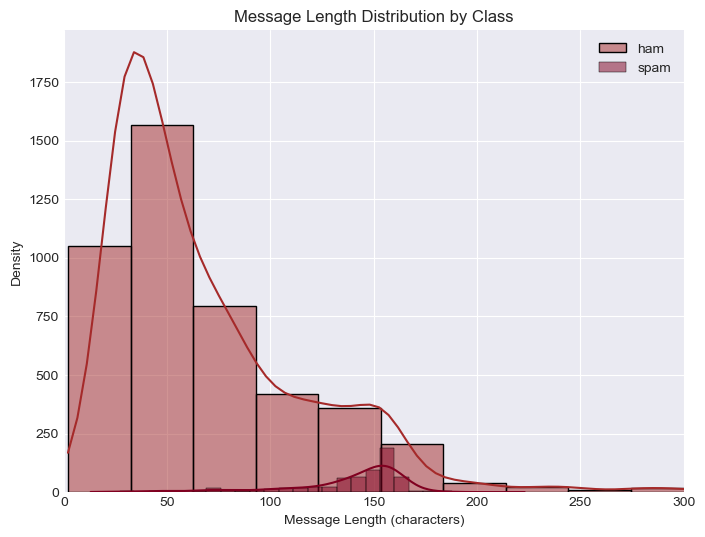

In [12]:
# Plot 1: Message Length Distribution by Class
plt.figure(figsize=(8, 6))  # Set figure size
colors = ['#A52A2A', '#800020']  # Brown for ham, Burgundy for spam

# Loop through each class to plot histogram
for label, color in zip(['ham', 'spam'], colors):
    subset = df[df['label'] == label]['message_length']  # Select message lengths for current class
    sns.histplot(subset, label=label, color=color, kde=True, alpha=0.5, bins=30)  # Histogram with KDE overlay

plt.xlabel('Message Length (characters)')  # X-axis label
plt.ylabel('Density')  # Y-axis label
plt.title('Message Length Distribution by Class')  # Plot title
plt.legend()  # Add legend
plt.xlim(0, 300)  # Limit x-axis for better visualization
plt.show()  # Display plot

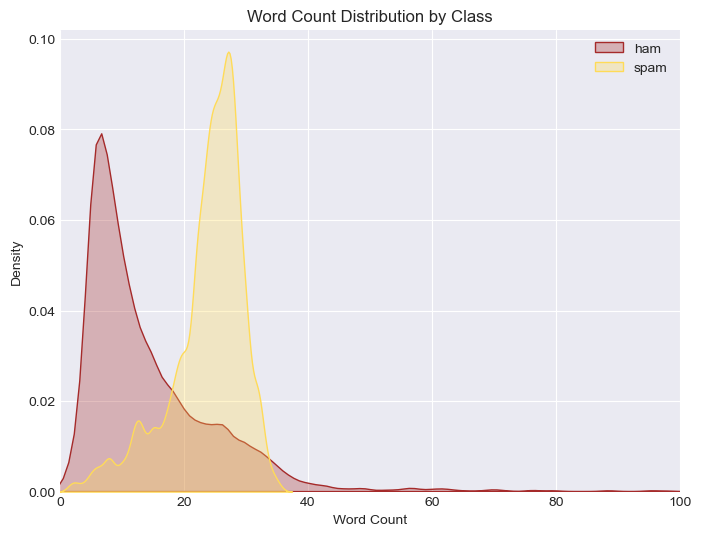

In [13]:
# Plot 2: Word Count Distribution by Class
plt.figure(figsize=(8, 6))  # Set figure size
colors = ['#A52A2A', '#FFDB58']  # Brown for ham, Mustard yellow for spam

# Loop through each class to plot KDE for word count
for label, color in zip(['ham', 'spam'], colors):
    subset = df[df['label'] == label]['word_count']  # Select word counts for current class
    sns.kdeplot(subset, label=label, color=color, fill=True, alpha=0.3, bw_adjust=0.5)  # KDE plot with filled area

plt.xlabel('Word Count')  # X-axis label
plt.ylabel('Density')  # Y-axis label
plt.title('Word Count Distribution by Class')  # Plot title
plt.legend()  # Add legend
plt.xlim(0, 100)  # Limit x-axis
plt.show()  # Display plot

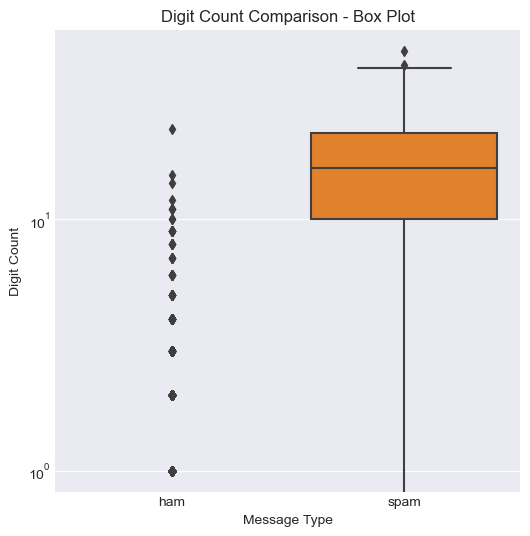

In [14]:
# Plot 3: Digit Count Comparison - Box Plot
plt.figure(figsize=(6, 6))  # Set figure size
colors = ['#1f77b4', '#ff7f0e']  # Blue for ham, Orange for spam

sns.boxplot(x='label', y='digit_count', data=df, palette=colors)  # Box plot of digit counts by class
plt.xlabel('Message Type')  # X-axis label
plt.ylabel('Digit Count')  # Y-axis label
plt.title('Digit Count Comparison - Box Plot')  # Plot title
plt.yscale('log')  # Log scale due to wide value range
plt.show()  # Display plot

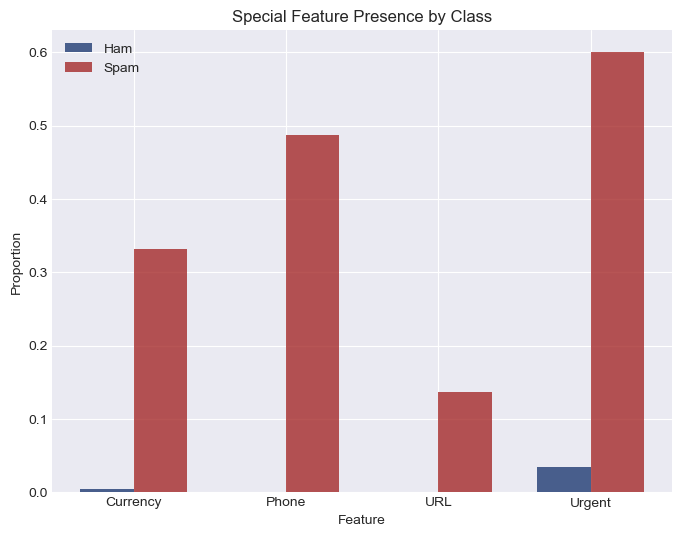

In [15]:
# Plot 4: Special Feature Presence by Class
plt.figure(figsize=(8, 6))  # Set figure size

# Define special features to analyze
features = ['contains_currency', 'contains_phone', 'contains_url', 'contains_urgent']

# Calculate mean (proportion) of each feature for ham and spam messages
ham_props = [df[df['label'] == 'ham'][f].mean() for f in features]
spam_props = [df[df['label'] == 'spam'][f].mean() for f in features]

# Define positions for grouped bar chart
x = np.arange(len(features))
width = 0.35  # Width of bars

# Plot bars for ham and spam
plt.bar(x - width/2, ham_props, width, label='Ham', color='#1f3b73', alpha=0.8)  # Dark blue for Ham
plt.bar(x + width/2, spam_props, width, label='Spam', color='#A52A2A', alpha=0.8)   # Brown for Spam

plt.xticks(x, ['Currency', 'Phone', 'URL', 'Urgent'])  # Set x-axis tick labels
plt.xlabel('Feature')  # X-axis label
plt.ylabel('Proportion')  # Y-axis label
plt.title('Special Feature Presence by Class')  # Plot title
plt.legend()  # Add legend
plt.show()  # Display plot

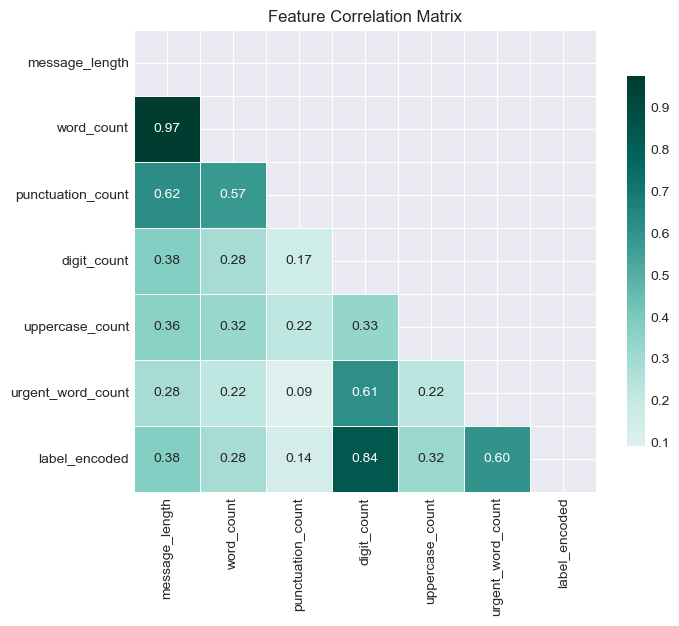

In [16]:
# Plot 5: Feature Correlation Matrix
plt.figure(figsize=(8, 6))  # Set figure size

# Select numeric features for correlation
numeric_features = ['message_length', 'word_count', 'punctuation_count', 
                    'digit_count', 'uppercase_count', 'urgent_word_count']

# Encode label as numeric for correlation
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

# Compute correlation matrix
corr = df[numeric_features + ['label_encoded']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Mask upper triangle

# Plot heatmap
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='BrBG',  # BrBG for brown & yellow-greenish tones
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix')  # Plot title
plt.show()  # Display plot

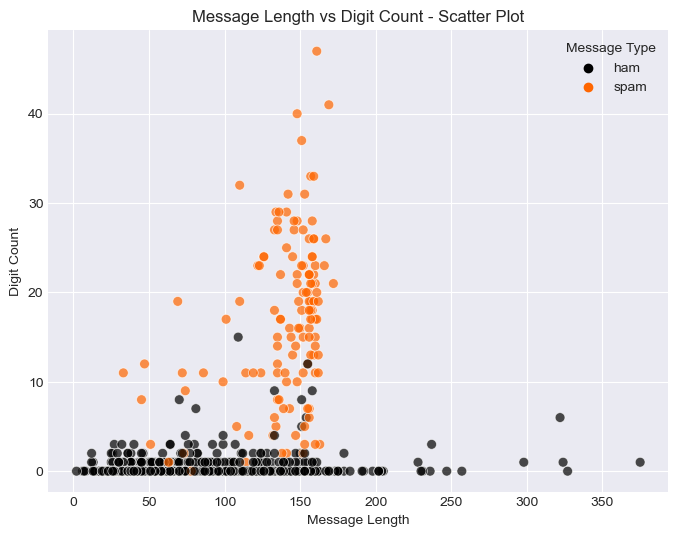

In [17]:
# Plot 6: Scatter Plot of Message Length vs Digit Count
plt.figure(figsize=(8, 6))  # Set figure size

# Sample 1000 messages for scatter plot to improve readability
sample_df = df.sample(1000, random_state=42)
colors = {'ham': '#000000', 'spam': '#FF6600'}  # Black for ham, Orange for spam

# Create scatter plot
sns.scatterplot(data=sample_df, x='message_length', y='digit_count', 
                hue='label', palette=colors, alpha=0.7, s=50)

plt.xlabel('Message Length')  # X-axis label
plt.ylabel('Digit Count')  # Y-axis label
plt.title('Message Length vs Digit Count - Scatter Plot')  # Plot title
plt.legend(title='Message Type')  # Add legend with title
plt.show()  # Display plot

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 12: Create Text Analysis Visualizations
</h3>

Creating Top 20 Ham Words Plot...


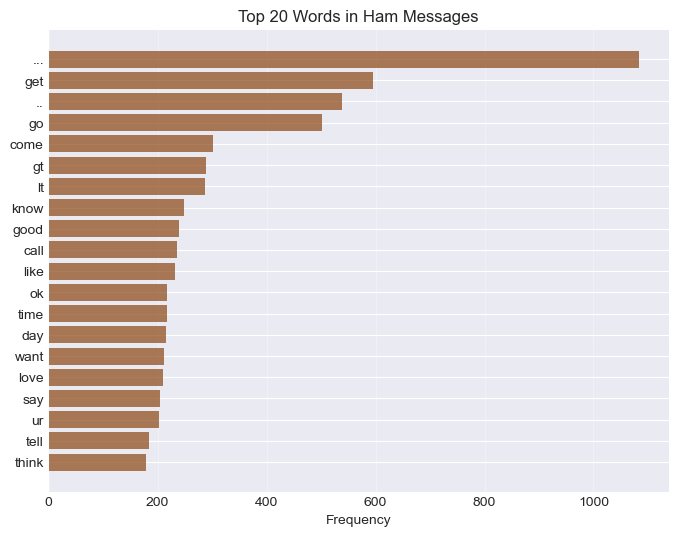

In [18]:
print("Creating Top 20 Ham Words Plot...")  # Status message

# Separate clean ham text
ham_messages = df[df['label'] == 'ham']['clean_text']  # Ham messages

# Get top words function
def get_top_words(text_series, n=20, min_length=2):  # Function to get top words
    all_words = []  # Initialize empty list
    for text in text_series:  # Loop over messages
        words = text.split()  # Split into words
        all_words.extend([word for word in words if len(word) >= min_length])  # Filter short words
    word_freq = Counter(all_words)  # Count word frequency
    return word_freq.most_common(n)  # Return top n words

top_ham_words = get_top_words(ham_messages, 20)  # Top 20 ham words

# Create figure for plot
plt.figure(figsize=(8,6))  # Set figure size
ham_words, ham_freqs = zip(*top_ham_words)  # Unpack words and frequencies
plt.barh(range(len(ham_words)), ham_freqs, color='#8B4513', alpha=0.7)  # Brown bars
plt.yticks(range(len(ham_words)), ham_words)  # Set y-axis labels
plt.xlabel('Frequency')  # X-axis label
plt.title('Top 20 Words in Ham Messages')  # Plot title
plt.gca().invert_yaxis()  # Highest frequency on top
plt.grid(True, alpha=0.3, axis='x')  # Add grid
plt.show()  # Display plot

Creating Top 20 Spam Words Plot...


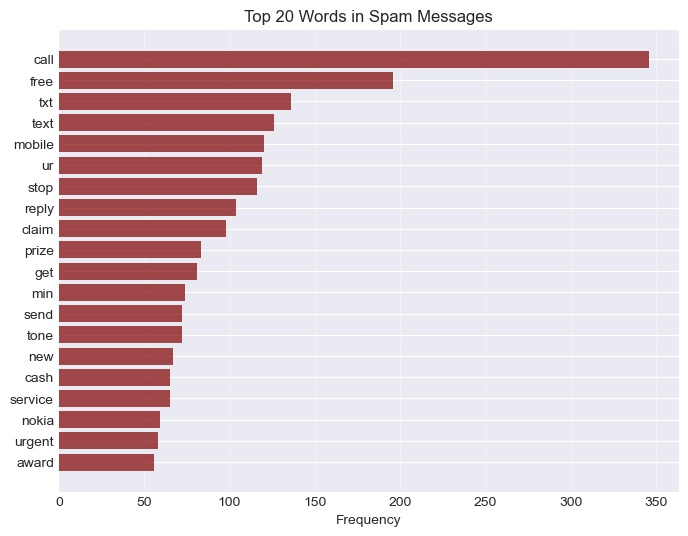

In [19]:
print("Creating Top 20 Spam Words Plot...")  # Status message

# Separate clean spam text
spam_messages = df[df['label'] == 'spam']['clean_text']  # Spam messages
top_spam_words = get_top_words(spam_messages, 20)  # Top 20 spam words

# Create figure for plot
plt.figure(figsize=(8,6))  # Set figure size
spam_words, spam_freqs = zip(*top_spam_words)  # Unpack words and frequencies
plt.barh(range(len(spam_words)), spam_freqs, color='#800000', alpha=0.7)  # Burgundy bars
plt.yticks(range(len(spam_words)), spam_words)  # Set y-axis labels
plt.xlabel('Frequency')  # X-axis label
plt.title('Top 20 Words in Spam Messages')  # Plot title
plt.gca().invert_yaxis()  # Highest frequency on top
plt.grid(True, alpha=0.3, axis='x')  # Add grid
plt.show()  # Display plot

Creating Ham Word Cloud...


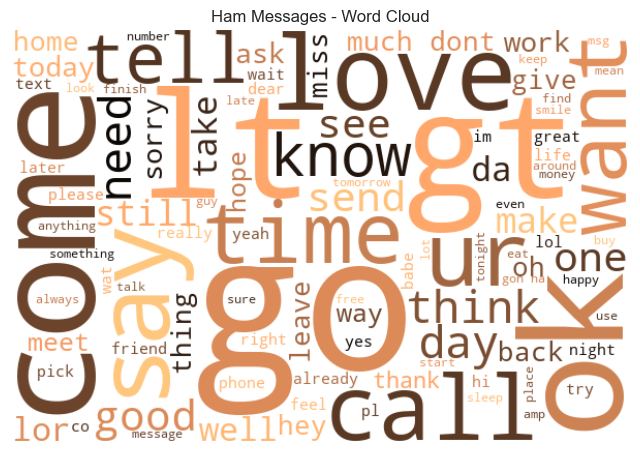

In [20]:
print("Creating Ham Word Cloud...")  # Status message

# Combine all ham messages
ham_text = ' '.join(ham_messages)  # Single string for word cloud

# Generate WordCloud
ham_wordcloud = WordCloud(width=600, height=400, background_color='white',
                          max_words=100, colormap='copper').generate(ham_text)  # Word cloud

# Display word cloud using PIL conversion to avoid 'copy' error
plt.figure(figsize=(8,6))  # Set figure size
from PIL import Image  # Import PIL for image conversion
plt.imshow(np.array(ham_wordcloud.to_image()), interpolation='bilinear')  # Display image
plt.axis('off')  # Remove axes
plt.title('Ham Messages - Word Cloud')  # Plot title
plt.show()  # Display plot

Creating Spam Word Cloud...


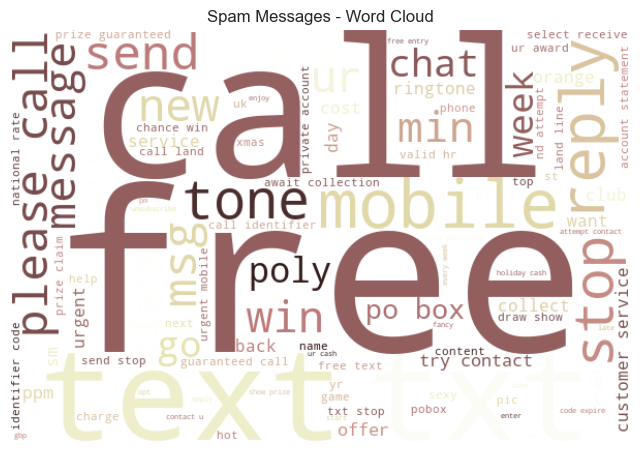

In [21]:
print("Creating Spam Word Cloud...")  # Status message

# Combine all spam messages
spam_text = ' '.join(spam_messages)  # Single string for word cloud

# Generate WordCloud
spam_wordcloud = WordCloud(width=600, height=400, background_color='white',
                           max_words=100, colormap='pink').generate(spam_text)  # Word cloud

# Display word cloud using PIL conversion to avoid 'copy' error
plt.figure(figsize=(8,6))  # Set figure size
from PIL import Image  # Import PIL for image conversion
plt.imshow(np.array(spam_wordcloud.to_image()), interpolation='bilinear')  # Display image
plt.axis('off')  # Remove axes
plt.title('Spam Messages - Word Cloud')  # Plot title
plt.show()  # Display plot

<h2 style="
    color: #8B4513; 
    text-align: center; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 15px;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.3);
">
PHASE 6: DATA PREPARATION FOR MODELING
</h2>

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 13: Prepare Target Variable
</h3>

In [22]:
print("Preparing data for machine learning...")  # Status message

y = df['label_encoded']  # Target variable (0 = ham, 1 = spam)

print(f"Target variable shape: {y.shape}")  # Print shape of target variable
print(f"Class distribution: Ham={sum(y==0)}, Spam={sum(y==1)}")  # Class counts

X_text = df['clean_text']  # Text feature column

engineered_features = [
    col for col in df.columns 
    if col not in ['label', 'message', 'clean_text', 'label_encoded']
]  # Select engineered features

X_eng = df[engineered_features]  # Engineered feature set

print(f"\nText features shape: {X_text.shape}")  # Text feature shape
print(f"Engineered features shape: {X_eng.shape}")  # Engineered feature shape
print(f"Number of engineered features: {len(engineered_features)}")  # Feature count

scaler = StandardScaler()  # Initialize scaler

X_eng_scaled = scaler.fit_transform(X_eng)  # Scale engineered features

X_eng_scaled_df = pd.DataFrame(
    X_eng_scaled,
    columns=engineered_features,
    index=df.index
)  # Convert scaled features to DataFrame

print("\nEngineered features scaled successfully")  # Confirmation message
print("\n" + "=" * 80)  # Separator line

Preparing data for machine learning...
Target variable shape: (5169,)
Class distribution: Ham=4516, Spam=653

Text features shape: (5169,)
Engineered features shape: (5169, 17)
Number of engineered features: 17

Engineered features scaled successfully



<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 14: Split Data into Training and Testing Sets
</h3>

In [23]:
print("Splitting data into training and testing sets...")  # Status message

X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
    shuffle=True
)  # Stratified train-test split

X_eng_train = X_eng_scaled_df.loc[X_text_train.index]  # Engineered features (train)
X_eng_test = X_eng_scaled_df.loc[X_text_test.index]  # Engineered features (test)

print(f"Training set size: {len(X_text_train):,} samples")  # Training size
print(f"Test set size: {len(X_text_test):,} samples")  # Test size

print("\nTraining set class distribution:")  # Training distribution
print(f"  Ham: {sum(y_train==0):,} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  Spam: {sum(y_train==1):,} ({sum(y_train==1)/len(y_train)*100:.1f}%)")

print("\nTest set class distribution:")  # Test distribution
print(f"  Ham: {sum(y_test==0):,} ({sum(y_test==0)/len(y_test)*100:.1f}%)")
print(f"  Spam: {sum(y_test==1):,} ({sum(y_test==1)/len(y_test)*100:.1f}%)")

print("\n" + "=" * 80)  # Separator

Splitting data into training and testing sets...
Training set size: 4,135 samples
Test set size: 1,034 samples

Training set class distribution:
  Ham: 3,613 (87.4%)
  Spam: 522 (12.6%)

Test set class distribution:
  Ham: 903 (87.3%)
  Spam: 131 (12.7%)



<h2 style="
    color: #8B4513; 
    text-align: center; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 15px;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.3);
">
PHASE 7: FEATURE EXTRACTION
</h2>

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 15: Apply TF-IDF Vectorization
</h3>

In [24]:
print("Applying TF-IDF vectorization...")  # Status message

tfidf_vectorizer = TfidfVectorizer(  # Initialize TF-IDF vectorizer
    max_features=5000,               # Limit vocabulary size to top 5000 terms
    ngram_range=(1, 2),               # Use unigrams and bigrams
    min_df=2,                         # Ignore terms appearing in fewer than 2 documents
    max_df=0.9,                       # Ignore terms appearing in more than 90% of documents
    stop_words='english',             # Remove English stopwords
    sublinear_tf=True                 # Apply logarithmic scaling to term frequency
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_text_train)  # Fit on training text and transform
X_test_tfidf = tfidf_vectorizer.transform(X_text_test)        # Transform test text using fitted vectorizer

print("TF-IDF vectorization completed")  # Confirmation message

print(f"Training TF-IDF shape: {X_train_tfidf.shape}")  # Shape of training TF-IDF matrix
print(f"Test TF-IDF shape: {X_test_tfidf.shape}")       # Shape of test TF-IDF matrix

print(f"Vocabulary size: {len(tfidf_vectorizer.get_feature_names_out()):,} features")  # Vocabulary size

print("\n" + "=" * 80)  # Separator line

Applying TF-IDF vectorization...
TF-IDF vectorization completed
Training TF-IDF shape: (4135, 4793)
Test TF-IDF shape: (1034, 4793)
Vocabulary size: 4,793 features



<h2 style="
    color: #8B4513; 
    text-align: center; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 15px;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.3);
">
PHASE 8: BASELINE MODEL TRAINING
</h2>

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 16: Train Baseline Logistic Regression Model
</h3>

In [25]:
print("Training baseline Logistic Regression model...")  # Status message

logreg_model = LogisticRegression(  # Initialize Logistic Regression model
    random_state=42,                # Set random seed for reproducibility
    max_iter=1000,                  # Increase iterations to ensure convergence
    class_weight='balanced',        # Handle class imbalance between ham and spam
    solver='liblinear'              # Optimization algorithm suitable for small/medium datasets
)

logreg_model.fit(X_train_tfidf, y_train)  # Train Logistic Regression model

y_pred_logreg = logreg_model.predict(X_test_tfidf)  # Predict class labels on test data

y_pred_proba_logreg = logreg_model.predict_proba(X_test_tfidf)[:, 1]  # Get spam probability scores

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)  # Compute accuracy
precision_logreg = precision_score(y_test, y_pred_logreg)  # Compute precision
recall_logreg = recall_score(y_test, y_pred_logreg)  # Compute recall
f1_logreg = f1_score(y_test, y_pred_logreg)  # Compute F1-score

tn_logreg, fp_logreg, fn_logreg, tp_logreg = confusion_matrix(y_test, y_pred_logreg).ravel()  # Confusion matrix values

specificity_logreg = tn_logreg / (tn_logreg + fp_logreg)  # Calculate specificity (true negative rate)

print("Logistic Regression Results:")  # Results header
print(f"  Accuracy: {accuracy_logreg:.4f}")  # Accuracy score
print(f"  Precision: {precision_logreg:.4f}")  # Precision score
print(f"  Recall: {recall_logreg:.4f}")  # Recall score
print(f"  F1-Score: {f1_logreg:.4f}")  # F1-score
print(f"  Specificity: {specificity_logreg:.4f}")  # Specificity score
print(f"  Confusion Matrix: TN={tn_logreg}, FP={fp_logreg}, FN={fn_logreg}, TP={tp_logreg}")  # Confusion matrix

print("\n" + "=" * 80)  # Separator line

Training baseline Logistic Regression model...
Logistic Regression Results:
  Accuracy: 0.9768
  Precision: 0.8963
  Recall: 0.9237
  F1-Score: 0.9098
  Specificity: 0.9845
  Confusion Matrix: TN=889, FP=14, FN=10, TP=121



<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 17: Train Baseline SVM Model
</h3>

In [26]:
print("Training baseline SVM model...")  # Status message

svm_model = LinearSVC(                 # Initialize Linear Support Vector Machine
    random_state=42,                   # Set random seed for reproducibility
    dual=False,                        # Use primal optimization (better when n_samples > n_features)
    class_weight='balanced',           # Handle class imbalance between ham and spam
    max_iter=1000                      # Maximum iterations for convergence
)

svm_model.fit(X_train_tfidf, y_train)  # Train SVM model on TF-IDF features

y_pred_svm = svm_model.predict(X_test_tfidf)  # Predict class labels on test data

y_pred_proba_svm = expit(                      # Convert decision scores to probability-like values
    svm_model.decision_function(X_test_tfidf)
)

accuracy_svm = accuracy_score(y_test, y_pred_svm)  # Compute accuracy
precision_svm = precision_score(y_test, y_pred_svm)  # Compute precision
recall_svm = recall_score(y_test, y_pred_svm)  # Compute recall
f1_svm = f1_score(y_test, y_pred_svm)  # Compute F1-score

tn_svm, fp_svm, fn_svm, tp_svm = confusion_matrix(   # Extract confusion matrix values
    y_test, y_pred_svm
).ravel()

specificity_svm = tn_svm / (tn_svm + fp_svm)  # Calculate specificity (true negative rate)

print("SVM Results:")  # Results header
print(f"  Accuracy: {accuracy_svm:.4f}")  # Accuracy score
print(f"  Precision: {precision_svm:.4f}")  # Precision score
print(f"  Recall: {recall_svm:.4f}")  # Recall score
print(f"  F1-Score: {f1_svm:.4f}")  # F1-score
print(f"  Specificity: {specificity_svm:.4f}")  # Specificity score
print(f"  Confusion Matrix: TN={tn_svm}, FP={fp_svm}, FN={fn_svm}, TP={tp_svm}")  # Confusion matrix

print("\n" + "=" * 80)  # Separator line

Training baseline SVM model...
SVM Results:
  Accuracy: 0.9826
  Precision: 0.9248
  Recall: 0.9389
  F1-Score: 0.9318
  Specificity: 0.9889
  Confusion Matrix: TN=893, FP=10, FN=8, TP=123



<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 18: Create Baseline Model Comparison Visualization
</h3>

Creating baseline model comparison...


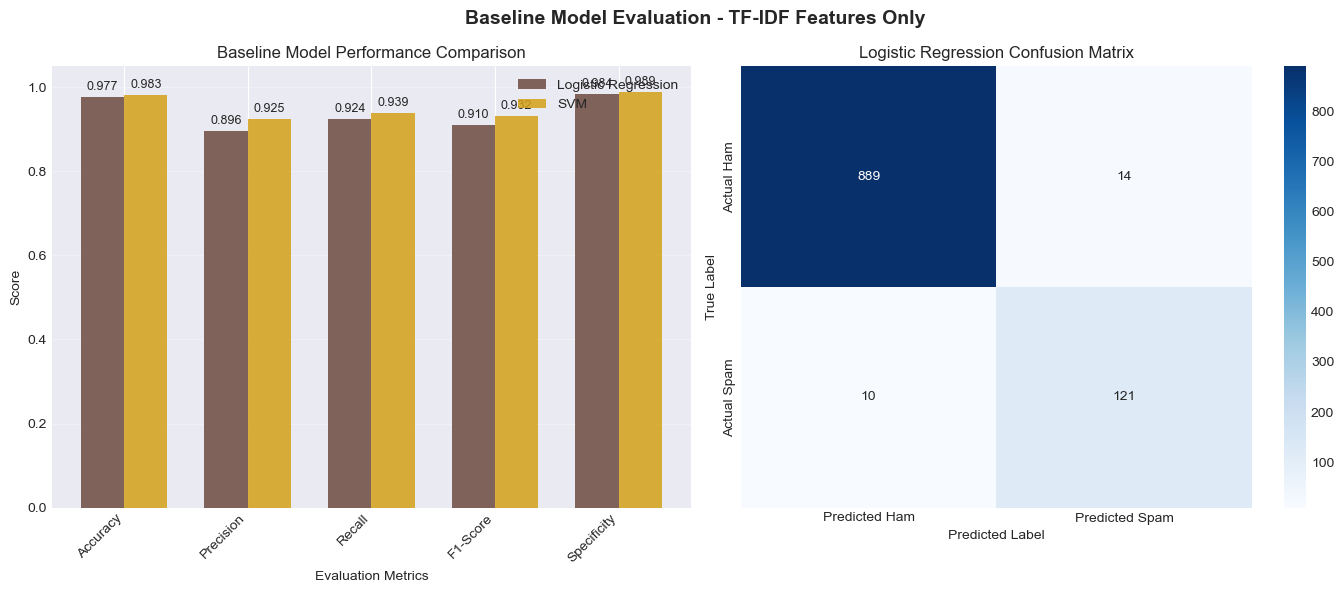

In [27]:
print("Creating baseline model comparison...")  # Status message

baseline_results = {                              # Store baseline model metrics
    'Logistic Regression': {
        'accuracy': accuracy_logreg,              # Accuracy score
        'precision': precision_logreg,            # Precision score
        'recall': recall_logreg,                  # Recall score
        'f1': f1_logreg,                          # F1-score
        'specificity': specificity_logreg         # Specificity score
    },
    'SVM': {
        'accuracy': accuracy_svm,                 # Accuracy score
        'precision': precision_svm,               # Precision score
        'recall': recall_svm,                     # Recall score
        'f1': f1_svm,                             # F1-score
        'specificity': specificity_svm            # Specificity score
    }
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))   # Create figure with two subplots

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity']  # Metric labels

metric_keys = ['accuracy', 'precision', 'recall', 'f1', 'specificity']   # Dictionary keys

x = np.arange(len(metrics))                    # X-axis positions
width = 0.35                                   # Bar width

logreg_values = [baseline_results['Logistic Regression'][k] for k in metric_keys]  # LogReg scores
svm_values = [baseline_results['SVM'][k] for k in metric_keys]                      # SVM scores

bars1 = axes[0].bar(                           # Logistic Regression bars
    x - width/2, logreg_values, width,
    label='Logistic Regression',
    color='#6D4C41',                           # Brown
    alpha=0.85
)

bars2 = axes[0].bar(                           # SVM bars
    x + width/2, svm_values, width,
    label='SVM',
    color='#D4A017',                           # Mustard Yellow
    alpha=0.85
)

axes[0].set_xlabel('Evaluation Metrics')        # X-axis label
axes[0].set_ylabel('Score')                     # Y-axis label
axes[0].set_title('Baseline Model Performance Comparison')  # Subplot title
axes[0].set_xticks(x)                           # Set x-ticks
axes[0].set_xticklabels(metrics, rotation=45, ha='right')  # Set tick labels
axes[0].set_ylim(0, 1.05)                       # Y-axis range
axes[0].legend(loc='upper right')               # Legend placement
axes[0].grid(True, axis='y', alpha=0.3)         # Grid lines

for bars in [bars1, bars2]:                     # Loop through both bar sets
    for bar in bars:
        height = bar.get_height()               # Bar height
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=9
        )

confusion_data = [                              # Confusion matrix values
    [tn_logreg, fp_logreg],
    [fn_logreg, tp_logreg]
]

sns.heatmap(                                    # Plot confusion matrix heatmap
    confusion_data,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Ham', 'Predicted Spam'],
    yticklabels=['Actual Ham', 'Actual Spam'],
    ax=axes[1]
)

axes[1].set_title('Logistic Regression Confusion Matrix')  # Heatmap title
axes[1].set_xlabel('Predicted Label')            # X-axis label
axes[1].set_ylabel('True Label')                 # Y-axis label

plt.suptitle(                                   # Main figure title
    'Baseline Model Evaluation - TF-IDF Features Only',
    fontsize=14, fontweight='bold'
)

plt.tight_layout()                              # Adjust layout
plt.show()                                      # Display plots

print("\n" + "=" * 80)                          # Separator line

<h2 style="
    color: #8B4513; 
    text-align: center; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 15px;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.3);
">
PHASE 9: HYPERPARAMETER TUNING
</h2>

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 19: Tune Logistic Regression Hyperparameters
</h3>

In [28]:
print("Performing hyperparameter tuning for Logistic Regression...")  # Status message

param_grid_logreg = {                                                  # Hyperparameter grid
    'C': [0.01, 0.1, 1, 10, 100],                                       # Regularization strengths
    'penalty': ['l1', 'l2'],                                           # L1 and L2 regularization
    'solver': ['liblinear'],                                           # Solver supporting L1 & L2
    'class_weight': ['balanced', None]                                 # Handle class imbalance
}

grid_search_logreg = GridSearchCV(                                     # GridSearch initialization
    estimator=LogisticRegression(                                      # Base Logistic Regression
        random_state=42,                                               # Reproducibility
        max_iter=1000                                                  # Max iterations
    ),
    param_grid=param_grid_logreg,                                      # Parameter combinations
    cv=3,                                                              # 3-fold cross-validation
    scoring='f1',                                                      # Optimize F1-score
    n_jobs=-1,                                                         # Use all CPU cores
    verbose=0                                                          # Silent execution
)

grid_search_logreg.fit(X_train_tfidf, y_train)                         # Train grid search

best_logreg = grid_search_logreg.best_estimator_                       # Best trained model
best_params_logreg = grid_search_logreg.best_params_                  # Best hyperparameters
best_score_logreg = grid_search_logreg.best_score_                    # Best CV F1 score

print(f"Best parameters: {best_params_logreg}")                        # Print best parameters
print(f"Best cross-validation F1 score: {best_score_logreg:.4f}")      # Print best CV score

y_pred_logreg_tuned = best_logreg.predict(X_test_tfidf)               # Test set predictions
y_pred_proba_logreg_tuned = best_logreg.predict_proba(                # Prediction probabilities
    X_test_tfidf
)[:, 1]

accuracy_logreg_tuned = accuracy_score(y_test, y_pred_logreg_tuned)   # Accuracy
precision_logreg_tuned = precision_score(y_test, y_pred_logreg_tuned) # Precision
recall_logreg_tuned = recall_score(y_test, y_pred_logreg_tuned)       # Recall
f1_logreg_tuned = f1_score(y_test, y_pred_logreg_tuned)               # F1-score

print("\nTuned Logistic Regression Test Results:")                     # Results header
print(f"  Accuracy: {accuracy_logreg_tuned:.4f}")                     # Accuracy output
print(f"  Precision: {precision_logreg_tuned:.4f}")                   # Precision output
print(f"  Recall: {recall_logreg_tuned:.4f}")                         # Recall output
print(f"  F1-Score: {f1_logreg_tuned:.4f}")                           # F1-score output

print("\n" + "=" * 80)                                                 # Separator line

Performing hyperparameter tuning for Logistic Regression...
Best parameters: {'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation F1 score: 0.8911

Tuned Logistic Regression Test Results:
  Accuracy: 0.9865
  Precision: 0.9535
  Recall: 0.9389
  F1-Score: 0.9462



<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 20: Tune SVM Hyperparameters
</h3>

In [29]:
print("Performing hyperparameter tuning for SVM...")                   # Status message

param_grid_svm = {                                                     # Hyperparameter grid
    'C': [0.01, 0.1, 1, 10, 100],                                       # Regularization strength
    'loss': ['hinge', 'squared_hinge'],                                # Loss functions
    'penalty': ['l2'],                                                 # Regularization type
    'class_weight': ['balanced', None]                                 # Handle class imbalance
}

grid_search_svm = GridSearchCV(                                        # GridSearch initialization
    estimator=LinearSVC(                                               # Base SVM model
        random_state=42,                                               # Reproducibility
        dual=False,                                                    # Use primal formulation
        max_iter=1000                                                  # Max iterations
    ),
    param_grid=param_grid_svm,                                         # Parameter combinations
    cv=3,                                                             # 3-fold cross-validation
    scoring='f1',                                                      # Optimize F1-score
    n_jobs=-1,                                                         # Use all CPU cores
    verbose=0                                                          # Silent execution
)

grid_search_svm.fit(X_train_tfidf, y_train)                            # Train grid search

best_svm = grid_search_svm.best_estimator_                             # Best trained SVM model
best_params_svm = grid_search_svm.best_params_                        # Best hyperparameters
best_score_svm = grid_search_svm.best_score_                          # Best CV F1 score

print(f"Best parameters: {best_params_svm}")                           # Print best parameters
print(f"Best cross-validation F1 score: {best_score_svm:.4f}")         # Print best CV score

y_pred_svm_tuned = best_svm.predict(X_test_tfidf)                     # Test set predictions

y_pred_proba_svm_tuned = expit(                                        # Probability-like scores
    best_svm.decision_function(X_test_tfidf)
)

accuracy_svm_tuned = accuracy_score(y_test, y_pred_svm_tuned)         # Accuracy
precision_svm_tuned = precision_score(y_test, y_pred_svm_tuned)       # Precision
recall_svm_tuned = recall_score(y_test, y_pred_svm_tuned)             # Recall
f1_svm_tuned = f1_score(y_test, y_pred_svm_tuned)                     # F1-score

print("\nTuned SVM Test Results:")                                     # Results header
print(f"  Accuracy: {accuracy_svm_tuned:.4f}")                        # Accuracy output
print(f"  Precision: {precision_svm_tuned:.4f}")                      # Precision output
print(f"  Recall: {recall_svm_tuned:.4f}")                            # Recall output
print(f"  F1-Score: {f1_svm_tuned:.4f}")                              # F1-score output

print("\n" + "=" * 80)                                                 # Separator line

Performing hyperparameter tuning for SVM...
Best parameters: {'C': 1, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'penalty': 'l2'}
Best cross-validation F1 score: 0.8923

Tuned SVM Test Results:
  Accuracy: 0.9826
  Precision: 0.9248
  Recall: 0.9389
  F1-Score: 0.9318



<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 21: Visualize Hyperparameter Tuning Results
</h3>

Visualizing hyperparameter tuning results...


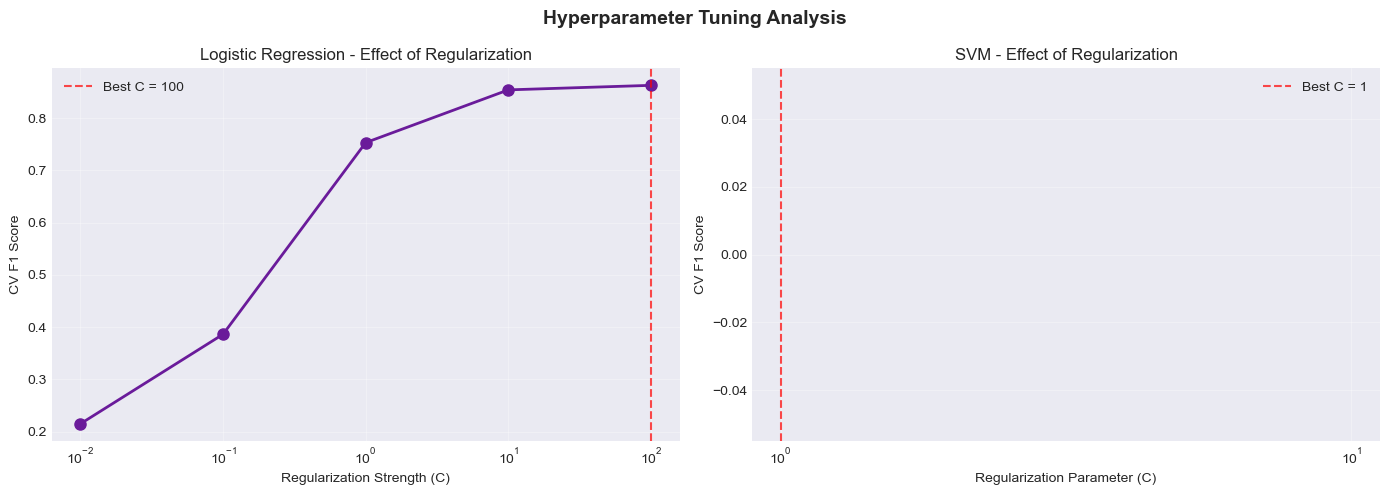

In [33]:
print("Visualizing hyperparameter tuning results...")                  # Status message

fig, axes = plt.subplots(1, 2, figsize=(14, 5))                        # Create figure with 2 subplots

c_values = param_grid_logreg['C']                                      # Extract Logistic Regression C values

mean_scores_logreg = []                                                # Store mean CV scores for LR

for c_val in c_values:                                                 # Loop through each C value
    indices = [                                                        # Find grid search indices for this C
        i for i, params in enumerate(grid_search_logreg.cv_results_['params'])
        if params['C'] == c_val
    ]
    if indices:                                                        # If matching configurations exist
        mean_score = np.mean([                                         # Compute mean CV score
            grid_search_logreg.cv_results_['mean_test_score'][i]
            for i in indices
        ])
        mean_scores_logreg.append(mean_score)                          # Append score

axes[0].plot(                                                          # Plot LR tuning curve
    c_values,
    mean_scores_logreg,
    marker='o',
    linewidth=2,
    markersize=8,
    color='#6A1B9A'
)

axes[0].set_xscale('log')                                              # Log scale for C
axes[0].set_xlabel('Regularization Strength (C)')                      # X-axis label
axes[0].set_ylabel('CV F1 Score')                                      # Y-axis label
axes[0].set_title('Logistic Regression - Effect of Regularization')    # Subplot title
axes[0].grid(True, alpha=0.3)                                          # Grid lines

best_c_logreg = best_params_logreg['C']                                # Best C from grid search

axes[0].axvline(                                                       # Vertical line at best C
    x=best_c_logreg,
    color='red',
    linestyle='--',
    alpha=0.7,
    label=f'Best C = {best_c_logreg}'
)

axes[0].legend()                                                       # Show legend

mean_scores_svm = []                                                   # Store mean CV scores for SVM

for c_val in param_grid_svm['C']:                                      # Loop through SVM C values
    indices = [                                                        # Find grid search indices
        i for i, params in enumerate(grid_search_svm.cv_results_['params'])
        if params['C'] == c_val
    ]
    if indices:                                                        # If matches exist
        mean_score = np.mean([                                         # Compute mean CV score
            grid_search_svm.cv_results_['mean_test_score'][i]
            for i in indices
        ])
        mean_scores_svm.append(mean_score)                             # Append score

axes[1].plot(                                                          # Plot SVM tuning curve
    param_grid_svm['C'],
    mean_scores_svm,
    marker='o',
    linewidth=2,
    markersize=8,
    color='#AD1457'
)

axes[1].set_xscale('log')                                              # Log scale for C
axes[1].set_xlabel('Regularization Parameter (C)')                     # X-axis label
axes[1].set_ylabel('CV F1 Score')                                      # Y-axis label
axes[1].set_title('SVM - Effect of Regularization')                    # Subplot title
axes[1].grid(True, alpha=0.3)                                          # Grid lines

best_c_svm = best_params_svm['C']                                      # Best C from grid search

axes[1].axvline(                                                       # Vertical line at best C
    x=best_c_svm,
    color='red',
    linestyle='--',
    alpha=0.7,
    label=f'Best C = {best_c_svm}'
)

axes[1].legend()                                                       # Show legend

plt.suptitle(                                                          # Main title
    'Hyperparameter Tuning Analysis',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()                                                     # Adjust layout spacing
plt.show()                                                             # Display plots

print("\n" + "=" * 80)                                                 # Separator line


<h2 style="
    color: #8B4513; 
    text-align: center; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 15px;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.3);
">
PHASE 10: COMBINED FEATURE MODELING
</h2>

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 22: Combine TF-IDF with Engineered Features
</h3>

In [34]:
print("Combining TF-IDF features with engineered features...")  # Status message

# ----------------------- CONVERT TF-IDF TO SPARSE ----------------------- #
# Ensure TF-IDF matrices are in Compressed Sparse Row format for stacking
X_train_tfidf_csr = X_train_tfidf.tocsr()  # Training set TF-IDF
X_test_tfidf_csr = X_test_tfidf.tocsr()    # Test set TF-IDF

# ------------------- CONVERT ENGINEERED FEATURES TO SPARSE ------------------- #
# Convert scaled engineered feature DataFrames to sparse matrices
X_eng_train_sparse = sparse.csr_matrix(X_eng_train.values)  # Training engineered
X_eng_test_sparse = sparse.csr_matrix(X_eng_test.values)    # Test engineered

# ------------------------ COMBINE FEATURES ------------------------ #
# Horizontally stack TF-IDF and engineered features
X_train_combined = sparse.hstack([X_train_tfidf_csr, X_eng_train_sparse])
X_test_combined = sparse.hstack([X_test_tfidf_csr, X_eng_test_sparse])

# ------------------------ PRINT FEATURE SET INFO ------------------------ #
print(f"Combined training features shape: {X_train_combined.shape}")  # Rows x Columns
print(f"Combined test features shape: {X_test_combined.shape}")      # Rows x Columns
print(f"Total number of features: {X_train_combined.shape[1]:,}")    # Number of columns

print("\n" + "="*80)  # Separator line for clarity

Combining TF-IDF features with engineered features...
Combined training features shape: (4135, 4810)
Combined test features shape: (1034, 4810)
Total number of features: 4,810



<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 23: Train Models with Combined Features
</h3>

In [35]:
print("Training models on combined features...")  # Status message

# ------------------------ LOGISTIC REGRESSION ------------------------ #
# Initialize Logistic Regression using best hyperparameters from tuning
logreg_combined = LogisticRegression(
    **best_params_logreg,  # Best hyperparameters
    random_state=42,       # Reproducibility
    max_iter=1000          # Maximum iterations for convergence
)

# Train Logistic Regression on combined features
logreg_combined.fit(X_train_combined, y_train)

# Predict labels on test set
y_pred_logreg_combined = logreg_combined.predict(X_test_combined)

# Predict probability scores for positive class (spam)
y_pred_proba_logreg_combined = logreg_combined.predict_proba(X_test_combined)[:, 1]

# Evaluate model performance
accuracy_logreg_combined = accuracy_score(y_test, y_pred_logreg_combined)
precision_logreg_combined = precision_score(y_test, y_pred_logreg_combined)
recall_logreg_combined = recall_score(y_test, y_pred_logreg_combined)
f1_logreg_combined = f1_score(y_test, y_pred_logreg_combined)

# Print Logistic Regression results
print(f"Logistic Regression with Combined Features:")
print(f"  Accuracy: {accuracy_logreg_combined:.4f}")
print(f"  Precision: {precision_logreg_combined:.4f}")
print(f"  Recall: {recall_logreg_combined:.4f}")
print(f"  F1-Score: {f1_logreg_combined:.4f}")

print("\n" + "="*80)  # Separator line for clarity

# ------------------------ SUPPORT VECTOR MACHINE ------------------------ #
# Initialize Linear SVM using best hyperparameters from tuning
svm_combined = LinearSVC(
    **best_params_svm,  # Best hyperparameters
    random_state=42,    # Reproducibility
    dual=False,         # Use primal optimization
    max_iter=1000       # Maximum iterations
)

# Train SVM on combined features
svm_combined.fit(X_train_combined, y_train)

# Predict labels on test set
y_pred_svm_combined = svm_combined.predict(X_test_combined)

# Convert decision function output to probability-like scores using sigmoid
y_pred_proba_svm_combined = expit(svm_combined.decision_function(X_test_combined))

# Evaluate SVM model performance
accuracy_svm_combined = accuracy_score(y_test, y_pred_svm_combined)
precision_svm_combined = precision_score(y_test, y_pred_svm_combined)
recall_svm_combined = recall_score(y_test, y_pred_svm_combined)
f1_svm_combined = f1_score(y_test, y_pred_svm_combined)

# Print SVM results
print(f"SVM with Combined Features:")
print(f"  Accuracy: {accuracy_svm_combined:.4f}")
print(f"  Precision: {precision_svm_combined:.4f}")
print(f"  Recall: {recall_svm_combined:.4f}")
print(f"  F1-Score: {f1_svm_combined:.4f}")

print("\n" + "="*80)  # Separator line for clarity

Training models on combined features...
Logistic Regression with Combined Features:
  Accuracy: 0.9884
  Precision: 0.9685
  Recall: 0.9389
  F1-Score: 0.9535

SVM with Combined Features:
  Accuracy: 0.9884
  Precision: 0.9685
  Recall: 0.9389
  F1-Score: 0.9535



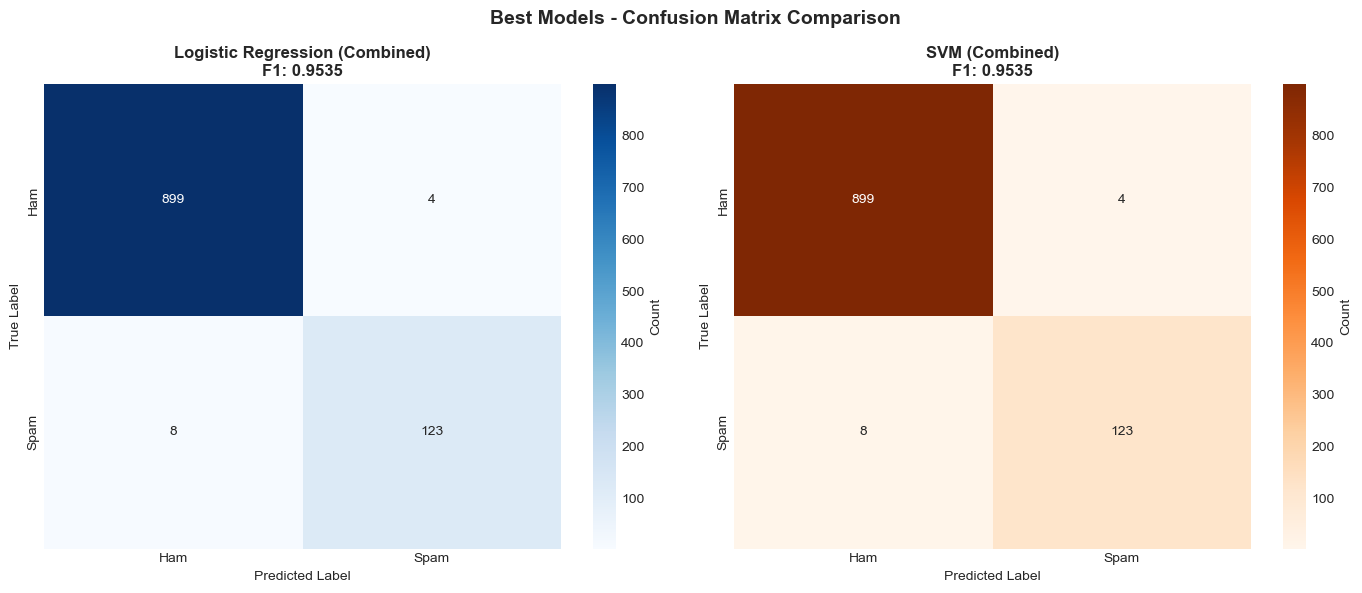


Confusion Matrix Analysis:
Logistic Regression - TN=899, FP=4, FN=8, TP=123
SVM - TN=899, FP=4, FN=8, TP=123


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Create a side-by-side layout for model comparison

cm_logreg = confusion_matrix(y_test, y_pred_logreg_combined)  # Compute confusion matrix for Logistic Regression
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',      # Visualize confusion matrix with count annotations
            xticklabels=['Ham', 'Spam'],                       # Define class labels for x-axis
            yticklabels=['Ham', 'Spam'],                       # Define class labels for y-axis
            ax=axes[0],                                        # Assign plot to the first subplot
            cbar_kws={'label': 'Count'})                       # Add color bar indicating sample count
axes[0].set_title(f'Logistic Regression (Combined)\nF1: {f1_logreg_combined:.4f}',  # Display model name and F1-score
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')                                # Label y-axis as true class
axes[0].set_xlabel('Predicted Label')                          # Label x-axis as predicted class

cm_svm = confusion_matrix(y_test, y_pred_svm_combined)         # Compute confusion matrix for SVM
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',       # Visualize confusion matrix with distinct color scheme
            xticklabels=['Ham', 'Spam'],                       # Define class labels for x-axis
            yticklabels=['Ham', 'Spam'],                       # Define class labels for y-axis
            ax=axes[1],                                        # Assign plot to the second subplot
            cbar_kws={'label': 'Count'})                       # Add color bar indicating sample count
axes[1].set_title(f'SVM (Combined)\nF1: {f1_svm_combined:.4f}', # Display model name and F1-score
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')                                # Label y-axis as true class
axes[1].set_xlabel('Predicted Label')                          # Label x-axis as predicted class

plt.suptitle('Best Models - Confusion Matrix Comparison',      # Add overall figure title for comparison
             fontsize=14, fontweight='bold')
plt.tight_layout()                                             # Adjust layout to prevent overlap
plt.show()                                                     # Render the visualization

print("\nConfusion Matrix Analysis:")                           # Print analytical summary header
print(f"Logistic Regression - TN={cm_logreg[0,0]}, FP={cm_logreg[0,1]}, FN={cm_logreg[1,0]}, TP={cm_logreg[1,1]}")  # Output confusion matrix components for Logistic Regression
print(f"SVM - TN={cm_svm[0,0]}, FP={cm_svm[0,1]}, FN={cm_svm[1,0]}, TP={cm_svm[1,1]}")                              # Output confusion matrix components for SVM


<h2 style="
    color: #8B4513; 
    text-align: center; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 15px;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.3);
">
PHASE 11: MODEL EVALUATION AND COMPARISON
</h2>

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 24: Create Comprehensive Model Comparison
</h3>

In [41]:
print("Creating comprehensive model comparison...")  # Status message

# ------------------------ STORE MODEL RESULTS ------------------------ #
# Dictionary to store evaluation metrics for all models
all_results = {
    'Logistic Regression (TF-IDF)': {
        'accuracy': accuracy_logreg,
        'precision': precision_logreg,
        'recall': recall_logreg,
        'f1': f1_logreg
    },
    'Logistic Regression (Tuned)': {
        'accuracy': accuracy_logreg_tuned,
        'precision': precision_logreg_tuned,
        'recall': recall_logreg_tuned,
        'f1': f1_logreg_tuned
    },
    'Logistic Regression (Combined)': {
        'accuracy': accuracy_logreg_combined,
        'precision': precision_logreg_combined,
        'recall': recall_logreg_combined,
        'f1': f1_logreg_combined
    },
    'SVM (TF-IDF)': {
        'accuracy': accuracy_svm,
        'precision': precision_svm,
        'recall': recall_svm,
        'f1': f1_svm
    },
    'SVM (Tuned)': {
        'accuracy': accuracy_svm_tuned,
        'precision': precision_svm_tuned,
        'recall': recall_svm_tuned,
        'f1': f1_svm_tuned
    },
    'SVM (Combined)': {
        'accuracy': accuracy_svm_combined,
        'precision': precision_svm_combined,
        'recall': recall_svm_combined,
        'f1': f1_svm_combined
    }
}

# ------------------------ CREATE COMPARISON TABLE ------------------------ #
# Convert dictionary to Pandas DataFrame for better readability
comparison_df = pd.DataFrame(all_results).T  # Transpose for easier reading

# Print the table with metrics rounded to 4 decimal places
print("\nModel Performance Comparison:")
print(comparison_df.round(4))

print("\n" + "="*80)  # Separator line for clarity


Creating comprehensive model comparison...

Model Performance Comparison:
                                accuracy  precision  recall      f1
Logistic Regression (TF-IDF)      0.9768     0.8963  0.9237  0.9098
Logistic Regression (Tuned)       0.9865     0.9535  0.9389  0.9462
Logistic Regression (Combined)    0.9884     0.9685  0.9389  0.9535
SVM (TF-IDF)                      0.9826     0.9248  0.9389  0.9318
SVM (Tuned)                       0.9826     0.9248  0.9389  0.9318
SVM (Combined)                    0.9884     0.9685  0.9389  0.9535



<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 25: Create Model Comparison Visualizations
</h3>

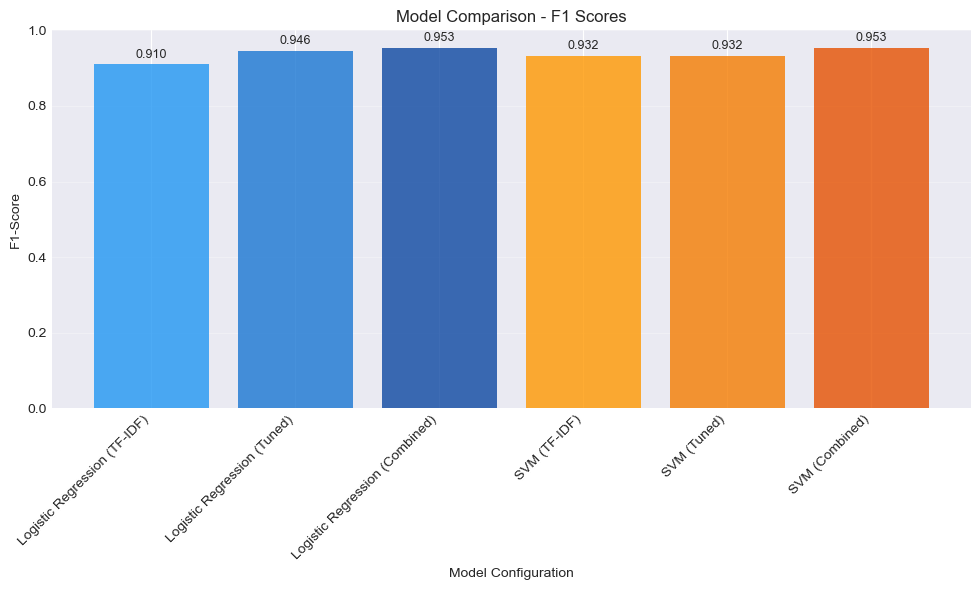

In [42]:
# -------------------------
# Plot 1: F1 Score Comparison
# -------------------------
plt.figure(figsize=(10, 6))  # Create separate figure
models = list(all_results.keys())  # List of model names
f1_scores = [all_results[model]['f1'] for model in models]  # Extract F1 scores
colors = ['#2196F3', '#1976D2', '#0D47A1', '#FF9800', '#F57C00', '#E65100']  # Color scheme

bars = plt.bar(models, f1_scores, color=colors, alpha=0.8)  # Bar chart

plt.xlabel('Model Configuration')  # X-axis label
plt.ylabel('F1-Score')  # Y-axis label
plt.title('Model Comparison - F1 Scores')  # Title
plt.ylim(0, 1)  # Y-axis limits
plt.xticks(rotation=45, ha='right')  # Rotate X labels for readability
plt.grid(True, alpha=0.3, axis='y')  # Grid lines along Y-axis

# Annotate bars with values
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{score:.3f}', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()  # Adjust layout
plt.show()  # Display plot

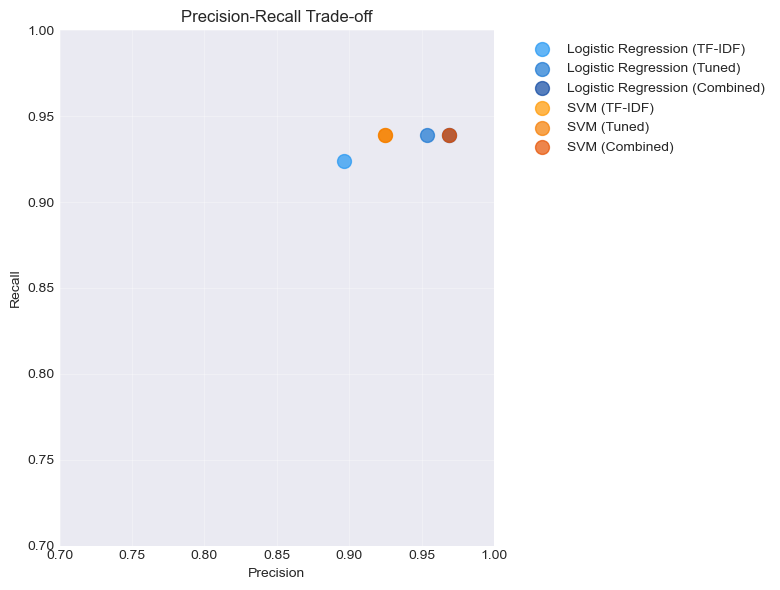

In [43]:
# -------------------------
# Plot 2: Precision-Recall Scatter Plot
# -------------------------
plt.figure(figsize=(8, 6))  # New figure

for i, model in enumerate(models):
    precision = all_results[model]['precision']  # Get precision
    recall = all_results[model]['recall']  # Get recall
    plt.scatter(precision, recall, s=100, color=colors[i], alpha=0.7, label=model)  # Scatter point

plt.xlabel('Precision')  # X-axis
plt.ylabel('Recall')  # Y-axis
plt.title('Precision-Recall Trade-off')  # Title
plt.xlim(0.7, 1.0)  # X-axis limits
plt.ylim(0.7, 1.0)  # Y-axis limits
plt.grid(True, alpha=0.3)  # Grid lines
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Legend outside plot
plt.tight_layout()  # Adjust layout
plt.show()  # Display plot

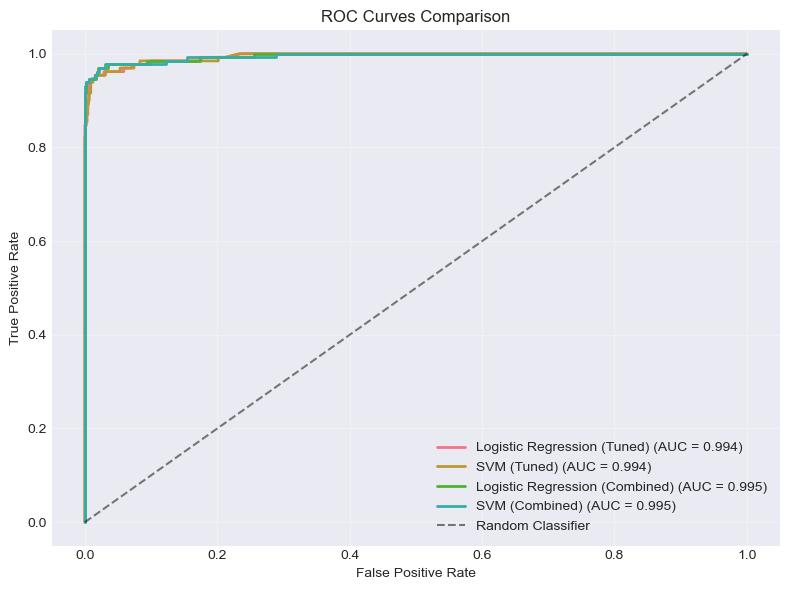

In [44]:
# -------------------------
# Plot 3: ROC Curves
# -------------------------
plt.figure(figsize=(8, 6))  # New figure

model_probas = [
    (y_pred_proba_logreg_tuned, 'Logistic Regression (Tuned)'),
    (y_pred_proba_svm_tuned, 'SVM (Tuned)'),
    (y_pred_proba_logreg_combined, 'Logistic Regression (Combined)'),
    (y_pred_proba_svm_combined, 'SVM (Combined)')
]

for proba, label in model_probas:
    fpr, tpr, _ = roc_curve(y_test, proba)  # Compute ROC points
    roc_auc = roc_auc_score(y_test, proba)  # Compute AUC
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.3f})', linewidth=2)  # Plot ROC

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')  # Diagonal reference line
plt.xlabel('False Positive Rate')  # X-axis
plt.ylabel('True Positive Rate')  # Y-axis
plt.title('ROC Curves Comparison')  # Title
plt.legend(loc='lower right')  # Legend
plt.grid(True, alpha=0.3)  # Grid
plt.tight_layout()  # Adjust layout
plt.show()  # Display plot

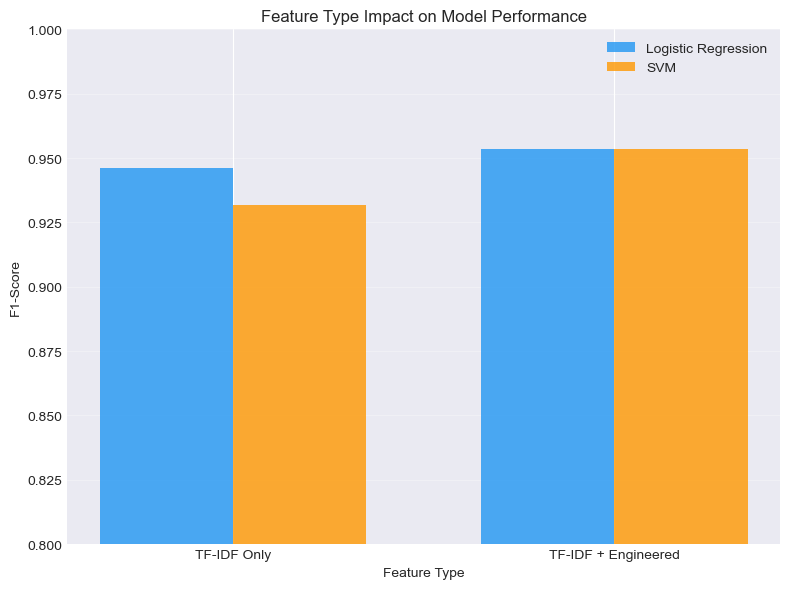

In [45]:
# -------------------------
# Plot 4: Feature Type Impact on F1
# -------------------------
plt.figure(figsize=(8, 6))  # New figure

feature_types = ['TF-IDF Only', 'TF-IDF + Engineered']  # Feature types
logreg_f1 = [all_results['Logistic Regression (Tuned)']['f1'], 
             all_results['Logistic Regression (Combined)']['f1']]  # LR F1
svm_f1 = [all_results['SVM (Tuned)']['f1'], 
          all_results['SVM (Combined)']['f1']]  # SVM F1

x = np.arange(len(feature_types))  # X positions
width = 0.35  # Bar width

bars1 = plt.bar(x - width/2, logreg_f1, width, label='Logistic Regression', color='#2196F3', alpha=0.8)
bars2 = plt.bar(x + width/2, svm_f1, width, label='SVM', color='#FF9800', alpha=0.8)

plt.xlabel('Feature Type')  # X-axis
plt.ylabel('F1-Score')  # Y-axis
plt.title('Feature Type Impact on Model Performance')  # Title
plt.xticks(x, feature_types)  # X-tick labels
plt.ylim(0.8, 1.0)  # Y-axis limits
plt.legend()  # Legend
plt.grid(True, alpha=0.3, axis='y')  # Grid lines
plt.tight_layout()  # Adjust layout
plt.show()  # Display plot

<Figure size 800x600 with 0 Axes>

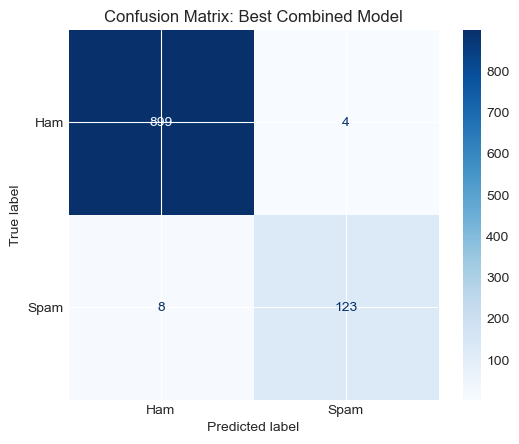

AttributeError: 'csr_matrix' object has no attribute 'index'

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_logreg_combined)

# 2. Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Best Combined Model')
plt.show()

# 3. Identify the specific errors (Misclassifications)
results_df = pd.DataFrame({
    'Message': X_test_tfidf.index, # Assuming index matches original text
    'Actual': y_test,
    'Predicted': y_pred_logreg_combined
})

# Filter for errors
errors = results_df[results_df['Actual'] != results_df['Predicted']]

print(f"\nTotal Errors: {len(errors)} out of {len(y_test)} test samples")
print("\nSample of messages the model got WRONG:")
# Merging with original dataframe to see the actual text of the errors
print(df.loc[errors.index, ['message', 'label']])

<h2 style="
    color: #8B4513; 
    text-align: center; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 15px;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.3);
">
PHASE 12: FEATURE IMPORTANCE ANALYSIS
</h2>

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 26: Analyze Feature Importance
</h3>

In [47]:
# Print status message for feature importance analysis
print("Analyzing feature importance...")  # Inform user that analysis is starting

# Determine best performing model based on F1 score
best_model_name = max(all_results.items(), key=lambda x: x[1]['f1'])[0]  # Select model with highest F1

# Print best model information
print(f"Best performing model: {best_model_name}")  # Show which model performed best

# Select appropriate model for feature importance analysis
if 'Logistic Regression' in best_model_name:  # If best model is Logistic Regression
    if 'Combined' in best_model_name:  # Check if it used combined features
        model_for_analysis = logreg_combined  # Use combined Logistic Regression model
    else:
        model_for_analysis = best_logreg  # Use tuned Logistic Regression model
else:  # SVM model
    if 'Combined' in best_model_name:  # Check if it used combined features
        model_for_analysis = svm_combined  # Use combined SVM model
    else:
        model_for_analysis = best_svm  # Use tuned SVM model

# Check if model has coefficients for feature importance analysis
if hasattr(model_for_analysis, 'coef_'):  # Only models with coef_ attribute can be analyzed
    # Extract coefficients from model
    coefficients = model_for_analysis.coef_[0]  # Flatten coefficients array for analysis
    
    # Get TF-IDF feature names from vectorizer
    tfidf_features = list(tfidf_vectorizer.get_feature_names_out())  # List of text feature names
    
    # Combine TF-IDF and engineered feature names
    all_features = tfidf_features + engineered_features  # Create combined feature list
    
    # Create DataFrame for feature importance analysis
    feature_importance_df = pd.DataFrame({  # Construct DataFrame
        'feature': all_features[:len(coefficients)],  # Feature names
        'coefficient': coefficients,  # Model coefficient values
        'abs_coefficient': np.abs(coefficients)  # Absolute values for ranking importance
    })
    
    # Sort features by absolute coefficient value (descending)
    feature_importance_df = feature_importance_df.sort_values('abs_coefficient', ascending=False)  # Rank by impact
    
    # Print top 10 most important features
    print(f"\nTop 10 most important features:")  # Header
    print(feature_importance_df.head(10).to_string(index=False))  # Display top features
    
    # Separate text features from engineered features
    text_features = feature_importance_df[feature_importance_df['feature'].isin(tfidf_features)]  # Only text features
    eng_features = feature_importance_df[feature_importance_df['feature'].isin(engineered_features)]  # Only engineered features
    
    # Print top 10 text features
    print(f"\nTop 10 text features:")  # Header
    print(text_features.head(10).to_string(index=False))  # Display top text features
    
    # Print engineered features importance
    print(f"\nEngineered features importance:")  # Header
    print(eng_features.sort_values('abs_coefficient', ascending=False).to_string(index=False))  # Display engineered feature impact

# Print separator line for visual clarity
print("\n" + "="*80)  # Visual separator for console output

Analyzing feature importance...
Best performing model: Logistic Regression (Combined)

Top 10 most important features:
feature  coefficient  abs_coefficient
   rgds     8.977995         8.977995
connect     8.517082         8.517082
divorce     7.694990         7.694990
arsenal     7.678050         7.678050
  reply     7.312586         7.312586
 mobile     7.024704         7.024704
    new     6.717113         6.717113
  enjoy     6.380260         6.380260
   text     6.057861         6.057861
service     6.057287         6.057287

Top 10 text features:
feature  coefficient  abs_coefficient
   rgds     8.977995         8.977995
connect     8.517082         8.517082
divorce     7.694990         7.694990
arsenal     7.678050         7.678050
  reply     7.312586         7.312586
 mobile     7.024704         7.024704
    new     6.717113         6.717113
  enjoy     6.380260         6.380260
   text     6.057861         6.057861
service     6.057287         6.057287

Engineered features i

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 27: Create Feature Importance Visualizations
</h3>

Visualizing feature importance...


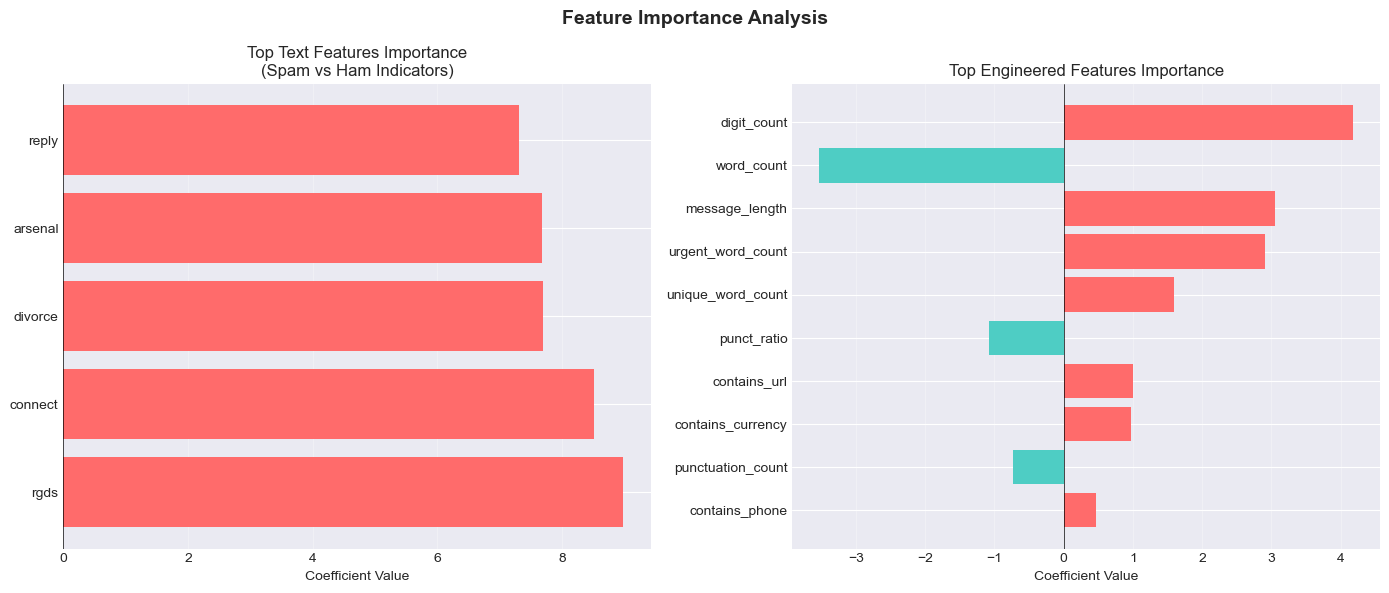

In [48]:
# Print status message for feature importance visualization
print("Visualizing feature importance...")  # Inform user that visualization is starting

# Prepare data for visualization
top_text_features = text_features.head(10)  # Select top 10 text features by importance
top_eng_features = eng_features.sort_values('abs_coefficient', ascending=False).head(10)  # Select top 10 engineered features

# Create figure for feature importance visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Create 1x2 subplot layout

# Separate positive and negative coefficients for text features
top_positive = top_text_features[top_text_features['coefficient'] > 0].head(5)  # Top positive (spam indicators)
top_negative = top_text_features[top_text_features['coefficient'] < 0].head(5)  # Top negative (ham indicators)

# Combine and sort text features by coefficient value
combined_text = pd.concat([top_positive, top_negative])  # Merge positive and negative features
combined_text = combined_text.sort_values('coefficient')  # Sort for horizontal bar plot display

# Create first subplot for text feature importance
bars1 = axes[0].barh(
    range(len(combined_text)),  # Y positions
    combined_text['coefficient'],  # Bar lengths (coefficients)
    color=['#FF6B6B' if x > 0 else '#4ECDC4' for x in combined_text['coefficient']]  # Red for positive, teal for negative
)

# Configure first subplot
axes[0].set_yticks(range(len(combined_text)))  # Set Y-axis positions
axes[0].set_yticklabels(combined_text['feature'])  # Set feature names as labels
axes[0].set_xlabel('Coefficient Value')  # Label X-axis
axes[0].set_title('Top Text Features Importance\n(Spam vs Ham Indicators)')  # Subplot title
axes[0].invert_yaxis()  # Invert Y-axis to show top feature on top
axes[0].axvline(x=0, color='black', linewidth=0.5)  # Vertical line at zero for reference
axes[0].grid(True, alpha=0.3, axis='x')  # Add horizontal grid lines

# Create second subplot for engineered feature importance
bars2 = axes[1].barh(
    range(len(top_eng_features)),  # Y positions
    top_eng_features['coefficient'],  # Bar lengths (coefficients)
    color=['#FF6B6B' if x > 0 else '#4ECDC4' for x in top_eng_features['coefficient']]  # Red for positive, teal for negative
)

# Configure second subplot
axes[1].set_yticks(range(len(top_eng_features)))  # Set Y-axis positions
axes[1].set_yticklabels(top_eng_features['feature'])  # Set engineered feature names as labels
axes[1].set_xlabel('Coefficient Value')  # Label X-axis
axes[1].set_title('Top Engineered Features Importance')  # Subplot title
axes[1].invert_yaxis()  # Invert Y-axis to show top feature on top
axes[1].axvline(x=0, color='black', linewidth=0.5)  # Vertical line at zero for reference
axes[1].grid(True, alpha=0.3, axis='x')  # Add horizontal grid lines

# Add main title for feature importance visualization
plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')  # Overall figure title

# Adjust layout to prevent overlapping elements
plt.tight_layout()  # Automatically adjust spacing

# Display feature importance visualizations
plt.show()  # Render the plots

# Print separator line for visual clarity
print("\n" + "="*80)  # Separator for console output

<h2 style="
    color: #8B4513; 
    text-align: center; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 15px;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.3);
">
PHASE 13: MODEL DEPLOYMENT AND TESTING
</h2>

<h3 style="
    color: #006400; 
    text-align: left; 
    font-family: 'Verdana', Geneva, sans-serif;
    margin-top: 20px;
">
Step 28: Save Best Model and Components
</h3>

In [49]:
# Print status message for model saving
print("Saving the best model and components...")

# Determine the best model based on F1 score from all_results
best_model_name = None
best_f1_score = 0

# Find the best performing model
if 'all_results' in locals() or 'all_results' in globals():
    for model_name, results in all_results.items():
        if results['f1'] > best_f1_score:
            best_f1_score = results['f1']
            best_model_name = model_name
    
    print(f"Best model identified: {best_model_name} (F1 Score: {best_f1_score:.4f})")
    
    # Select the appropriate model object based on the model name
    if 'Logistic Regression (Combined)' in best_model_name:
        model_to_save = logreg_combined
    elif 'Logistic Regression (Tuned)' in best_model_name:
        model_to_save = best_logreg
    elif 'Logistic Regression (TF-IDF)' in best_model_name:
        model_to_save = logreg_model
    elif 'SVM (Combined)' in best_model_name:
        model_to_save = svm_combined
    elif 'SVM (Tuned)' in best_model_name:
        model_to_save = best_svm
    elif 'SVM (TF-IDF)' in best_model_name:
        model_to_save = svm_model
    else:
        # Default to the combined SVM model
        model_to_save = svm_combined
        print("Using SVM (Combined) as default model")
else:
    # If all_results doesn't exist, use the combined SVM model as default
    model_to_save = svm_combined
    print("Using SVM (Combined) as default model")

# Create dictionary of components to save
components_to_save = {
    'best_model': model_to_save,
    'tfidf_vectorizer': tfidf_vectorizer,
    'feature_scaler': scaler,
    'engineered_features': engineered_features,
    'preprocessing_function': preprocess_text
}

# Save components to file using joblib
joblib.dump(components_to_save, 'sms_spam_classifier.pkl')

# Print confirmation message
print("Model and components saved successfully to 'sms_spam_classifier.pkl'")

# Print status message for model reloading demonstration
print("\nDemonstrating model reloading and prediction...")

# Load saved components from file
loaded_components = joblib.load('sms_spam_classifier.pkl')

# Extract individual components from loaded dictionary
loaded_model = loaded_components['best_model']
loaded_vectorizer = loaded_components['tfidf_vectorizer']
loaded_scaler = loaded_components['feature_scaler']
loaded_engineered_features = loaded_components['engineered_features']

# Define prediction function for SMS classification
def predict_sms_message(message, model, vectorizer, scaler, engineered_features_list, use_engineered=True):
    """
    Predict whether an SMS message is spam or ham.
    
    Parameters:
    message (str): SMS message to classify
    model: Trained classification model
    vectorizer: TF-IDF vectorizer
    scaler: Feature scaler for engineered features
    engineered_features_list: List of engineered feature names in correct order
    use_engineered (bool): Whether to use engineered features
    
    Returns:
    dict: Prediction results with probabilities
    """
    # Preprocess input message using preprocessing function
    processed_message = preprocess_text(message)

    # Apply TF-IDF transformation to processed message
    message_tfidf = vectorizer.transform([processed_message])

    # Check if engineered features should be used
    if use_engineered:
        # Get all words from the message
        words = message.split()
        unique_words = set(words)
        
        # Calculate all engineered features in the exact order they were during training
        features_dict = {
            'message_length': len(message),
            'word_count': len(words),
            'sentence_count': len(re.split(r'[.!?]+', message)) - 1,
            'punctuation_count': count_punctuation(message),
            'digit_count': count_digits(message),
            'uppercase_count': count_uppercase(message),
            'contains_currency': contains_currency(message),
            'contains_phone': contains_phone_number(message),
            'contains_url': contains_url(message),
            'contains_urgent': contains_urgent_words(message),
            'urgent_word_count': count_urgent_words(message),
            'punct_ratio': count_punctuation(message) / (len(message) + 1),
            'digit_ratio': count_digits(message) / (len(message) + 1),
            'uppercase_ratio': count_uppercase(message) / (len(message) + 1),
            'unique_word_count': len(unique_words),
            'avg_word_length': np.mean([len(word) for word in words]) if words else 0,
            'unique_word_ratio': len(unique_words) / (len(words) + 1),
            'urgent_word_ratio': count_urgent_words(message) / (len(words) + 1)
        }
        
        # Ensure all features from training are present
        # Create a DataFrame with the exact feature order from training
        features_df = pd.DataFrame({feature: [features_dict.get(feature, 0)] 
                                   for feature in engineered_features_list})
        
        # Scale engineered features using loaded scaler
        features_scaled = scaler.transform(features_df)
        
        # Convert scaled features to sparse matrix
        features_sparse = sparse.csr_matrix(features_scaled)
        
        # Combine TF-IDF and engineered features
        message_features = sparse.hstack([message_tfidf, features_sparse])
    else:
        # Use only TF-IDF features
        message_features = message_tfidf

    # Make prediction using loaded model
    prediction = model.predict(message_features)[0]

    # Convert numerical prediction to label
    prediction_label = 'spam' if prediction == 1 else 'ham'

    # Get probability scores if model supports predict_proba
    if hasattr(model, 'predict_proba'):
        probability = model.predict_proba(message_features)[0]
    else:
        # For SVM models, use decision function and sigmoid conversion
        decision_score = model.decision_function(message_features)[0]
        probability = expit(decision_score)
        probability = np.array([1 - probability, probability])

    # Return prediction results dictionary
    return {
        'message': message[:100] + '...' if len(message) > 100 else message,
        'prediction': prediction_label,
        'probability_ham': probability[0] if isinstance(probability, np.ndarray) else 1 - probability,
        'probability_spam': probability[1] if isinstance(probability, np.ndarray) else probability,
        'confidence': max(probability) if isinstance(probability, np.ndarray) else max(probability, 1-probability)
    }

# Print header for test predictions
print("\nTesting with sample messages from the dataset:")

# Select 5 random messages from dataset for testing
test_messages = df.sample(5, random_state=42)['message'].tolist()

# Iterate through test messages and make predictions
for i, message in enumerate(test_messages, 1):
    # Make prediction using loaded model
    result = predict_sms_message(message, loaded_model, loaded_vectorizer, loaded_scaler, loaded_engineered_features)
    
    # Print prediction results for each test message
    print(f"\nTest {i}:")
    print(f"  Message: {result['message']}")
    print(f"  Prediction: {result['prediction'].upper()}")
    print(f"  Confidence: {result['confidence']:.3f}")
    print(f"  Probabilities - Ham: {result['probability_ham']:.3f}, Spam: {result['probability_spam']:.3f}")

# Also test with some obvious spam and ham examples from the dataset
print("\n" + "="*80)
print("Additional testing with obvious examples:")

# Find obvious spam examples (containing typical spam keywords)
obvious_spam_samples = df[df['message'].str.contains('free|win|prize|claim|congratulations', case=False, na=False)].sample(2, random_state=42)['message'].tolist()

# Find obvious ham examples (short conversational messages)
obvious_ham_samples = df[(df['label'] == 'ham') & (df['word_count'] < 10)].sample(2, random_state=42)['message'].tolist()

print("\nObvious Spam examples:")
for i, message in enumerate(obvious_spam_samples, 1):
    result = predict_sms_message(message, loaded_model, loaded_vectorizer, loaded_scaler, loaded_engineered_features)
    print(f"\n  Spam Test {i}:")
    print(f"    Message: {result['message'][:80]}...")
    print(f"    Prediction: {result['prediction'].upper()} (Expected: SPAM)")
    print(f"    Confidence: {result['confidence']:.3f}")

print("\nObvious Ham examples:")
for i, message in enumerate(obvious_ham_samples, 1):
    result = predict_sms_message(message, loaded_model, loaded_vectorizer, loaded_scaler, loaded_engineered_features)
    print(f"\n  Ham Test {i}:")
    print(f"    Message: {result['message'][:80]}...")
    print(f"    Prediction: {result['prediction'].upper()} (Expected: HAM)")
    print(f"    Confidence: {result['confidence']:.3f}")

# Print final completion message
print("\n" + "="*80)
print("SMS Spam Classification Project Completed Successfully")

# Summary of saved model performance
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY:")
print("="*80)
print(f"Best Model Saved: {best_model_name}")
print(f"F1 Score: {best_f1_score:.4f}")
print(f"Total Features: {len(tfidf_vectorizer.get_feature_names_out()) + len(engineered_features)}")
print(f"  - TF-IDF Features: {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"  - Engineered Features: {len(engineered_features)}")
print(f"Model saved to: sms_spam_classifier.pkl")

Saving the best model and components...
Best model identified: Logistic Regression (Combined) (F1 Score: 0.9535)
Model and components saved successfully to 'sms_spam_classifier.pkl'

Demonstrating model reloading and prediction...

Testing with sample messages from the dataset:

Test 1:
  Message: K, makes sense, btw carlos is being difficult so you guys are gonna smoke while I go pick up the sec...
  Prediction: HAM
  Confidence: 1.000
  Probabilities - Ham: 1.000, Spam: 0.000

Test 2:
  Message: URGENT! Your mobile No *********** WON a £2,000 Bonus Caller Prize on 02/06/03! This is the 2nd atte...
  Prediction: SPAM
  Confidence: 1.000
  Probabilities - Ham: 0.000, Spam: 1.000

Test 3:
  Message: If you still havent collected the dough pls let me know so i can go to the place i sent it to get th...
  Prediction: HAM
  Confidence: 1.000
  Probabilities - Ham: 1.000, Spam: 0.000

Test 4:
  Message: Wat time do u wan 2 meet me later?
  Prediction: HAM
  Confidence: 1.000
  Probabilities